last version with right number of exposure for the whole LSST survey (https://arxiv.org/pdf/0805.2366.pdf)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import logging
import galsim
import random
import cmath as cm
import math
import scipy
import scipy.stats as stats
from astropy.io import fits
from astropy.cosmology import WMAP9 as cosmo
%matplotlib inline
import tensorflow as tf
import seaborn as sns
from importlib import reload
import pandas as pd
import matplotlib
import matplotlib as mpl
from tensorflow.keras import backend as K


from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')

KeyboardInterrupt: 

In [ ]:
sys.path.insert(0,'../../scripts/tools_for_VAE/')
import tools_for_VAE

from tools_for_VAE import vae_functions, model, plot, generator, results_processing, utils, boxplot, layers

from tools_for_VAE.results_processing import processing
from tools_for_VAE.boxplot import boxplot_func

# Loading the trained VAE

In [ ]:
nb_of_bands = 6
batch_size = 256

input_shape = (59, 59, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 2
filters = [32,64,128,256]
kernels = [3,3,3,3]

In [ ]:
net_psf = model.create_model_wo_ls_peak_pooling_vae_3(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)
net_no_psf = model.create_model_wo_ls_peak_pooling_vae_4(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

In [ ]:
loading_path_1 = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/v_vae_psf/loss/'
loading_path_2 = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/v_vae_no_psf_2/loss/'

In [ ]:
latest = tf.train.latest_checkpoint(loading_path_1)
net_psf.load_weights(latest)

latest = tf.train.latest_checkpoint(loading_path_2)
net_no_psf.load_weights(latest)

# Load data

In [7]:
## Compute lensed ellipticities from shear and 
def calc_lensed_ellipticity_1(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =  es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.real(e)

def calc_lensed_ellipticity_2(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.imag(e)

def calc_lensed_ellipticity(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.absolute(e)

ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

In [8]:
root_dir = "/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/test/"

images = np.load(root_dir+'img_noiseless_sample_2.npy', mmap_mode = 'c')
psf = np.load(root_dir+'psf_cropped_sample_2.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir+'img_noiseless_data_2.csv')

ell_1 = np.array(data['e1'])
ell_2 = np.array(data['e2'])
shear_1 = np.array(data['shear_1'])
shear_2 = np.array(data['shear_2'])
convergence = np.array(data['convergence'])

ellipticity = calc_lensed_ellipticity(-ell_1, ell_2, -shear_1, shear_2, convergence)
ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

e1 = ellipticity_conversion(calc_lensed_ellipticity_1(-ell_1, ell_2, -shear_1, shear_2, convergence))
e2 = ellipticity_conversion(calc_lensed_ellipticity_2(-ell_1, ell_2, -shear_1, shear_2, convergence))

In [9]:
e_in= np.sqrt(e1**2+e2**2)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
id                10000 non-null int64
e1                10000 non-null float64
e2                10000 non-null float64
shear_1           10000 non-null float64
shear_2           10000 non-null float64
redshift          10000 non-null float64
redshift_true     10000 non-null float64
blendedness       9999 non-null float64
snr_r             9998 non-null float64
convergence       10000 non-null float64
e1_hsm_regauss    9976 non-null float64
e2_hsm_regauss    9976 non-null float64
mag_r_meas        9998 non-null float64
mag_r_true        10000 non-null float64
dtypes: float64(13), int64(1)
memory usage: 1.1 MB


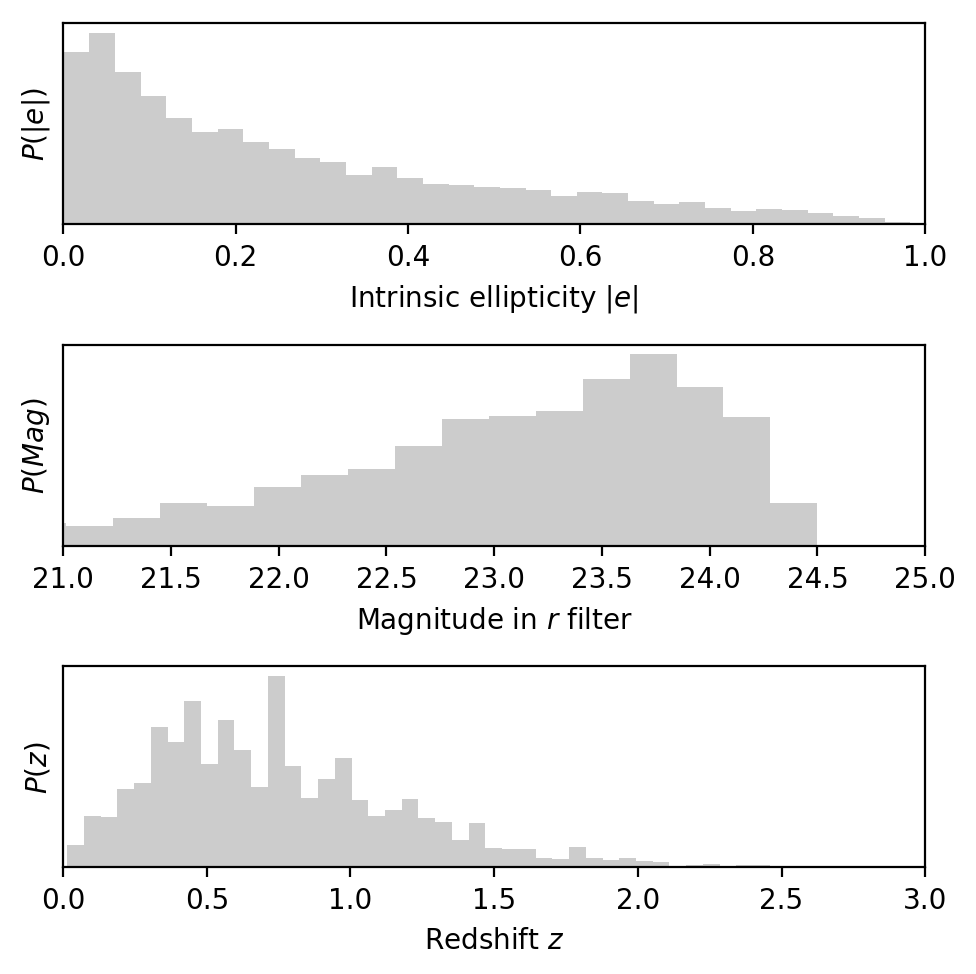

In [21]:
import matplotlib as mpl
mpl.rcdefaults()


fig, axes = plt.subplots(3, 1, figsize=(5,5), gridspec_kw={'height_ratios': [1,1,1]})

xlim = (0,1.)
sns.distplot(e_in, ax=axes[0], color='0.5', kde = False)
axes[0].set_xlim(xlim[0], xlim[1])
axes[0].set_ylabel('$P(|e|$)', fontsize = 10)
axes[0].set_yticks([])
axes[0].set_xlabel('Intrinsic ellipticity $|e|$')

xlim = (21,25.)
sns.distplot(data['mag_r_true'], ax=axes[1], color='0.5', kde = False)
axes[1].set_xlim(xlim[0], xlim[1])
axes[1].set_ylabel('$P(Mag)$', fontsize = 10)
axes[1].set_yticks([])
axes[1].set_xlabel('Magnitude in $r$ filter')

xlim = (0,3)
sns.distplot(data['redshift'], ax=axes[2], color='0.5', kde = False)
axes[2].set_xlim(xlim[0], xlim[1])
axes[2].set_ylabel('$P(z)$', fontsize = 10)
axes[2].set_yticks([])
axes[2].set_xlabel('Redshift $z$')


plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0.6)

fig.savefig('imgs/param_distrib.pdf', dpi = 300)

# Parameters to fix

In [11]:
stamp_size = 59 # pixels

bands_r = [2]
bands_lsst = [0,1,2,3,4,5]

batch_size = 100

In [12]:
pix_scale_lsst = 0.2

PSF = galsim.Kolmogorov(fwhm=0.65)

## With PSF

In [212]:
data_dir = "/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/test/"
root = 'img_noiseless'

images = np.load(root_dir+'img_noiseless_sample_2.npy', mmap_mode = 'c')
test_sample = [data_dir+'img_noiseless_sample_2.npy']

In [213]:
reload(results_processing)

<module 'tools_for_VAE.results_processing' from '../../scripts/tools_for_VAE/tools_for_VAE/results_processing.py'>

In [214]:
df_psf = results_processing.processing(net_psf,
                                     data_dir,                                           
                                     root,
                                     test_sample[0],
                                     bands_lsst,
                                     2,
                                     stamp_size, 
                                     batch_size,
                                     psf, 
                                     pix_scale_lsst)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99

(10000, 2, 2)


In [102]:
df_psf.to_csv('data/df_vae_dc2_psf.csv')

In [ ]:
df_psf = pd.read_csv('data/df_vae_dc2_psf.csv', encoding = 'utf-8')

### Shape plots

In [92]:
#df_psf = df_psf[(np.abs(df_psf['e1_in'])>0.02) & (np.abs(df_psf['e2_in'])>0.02)]

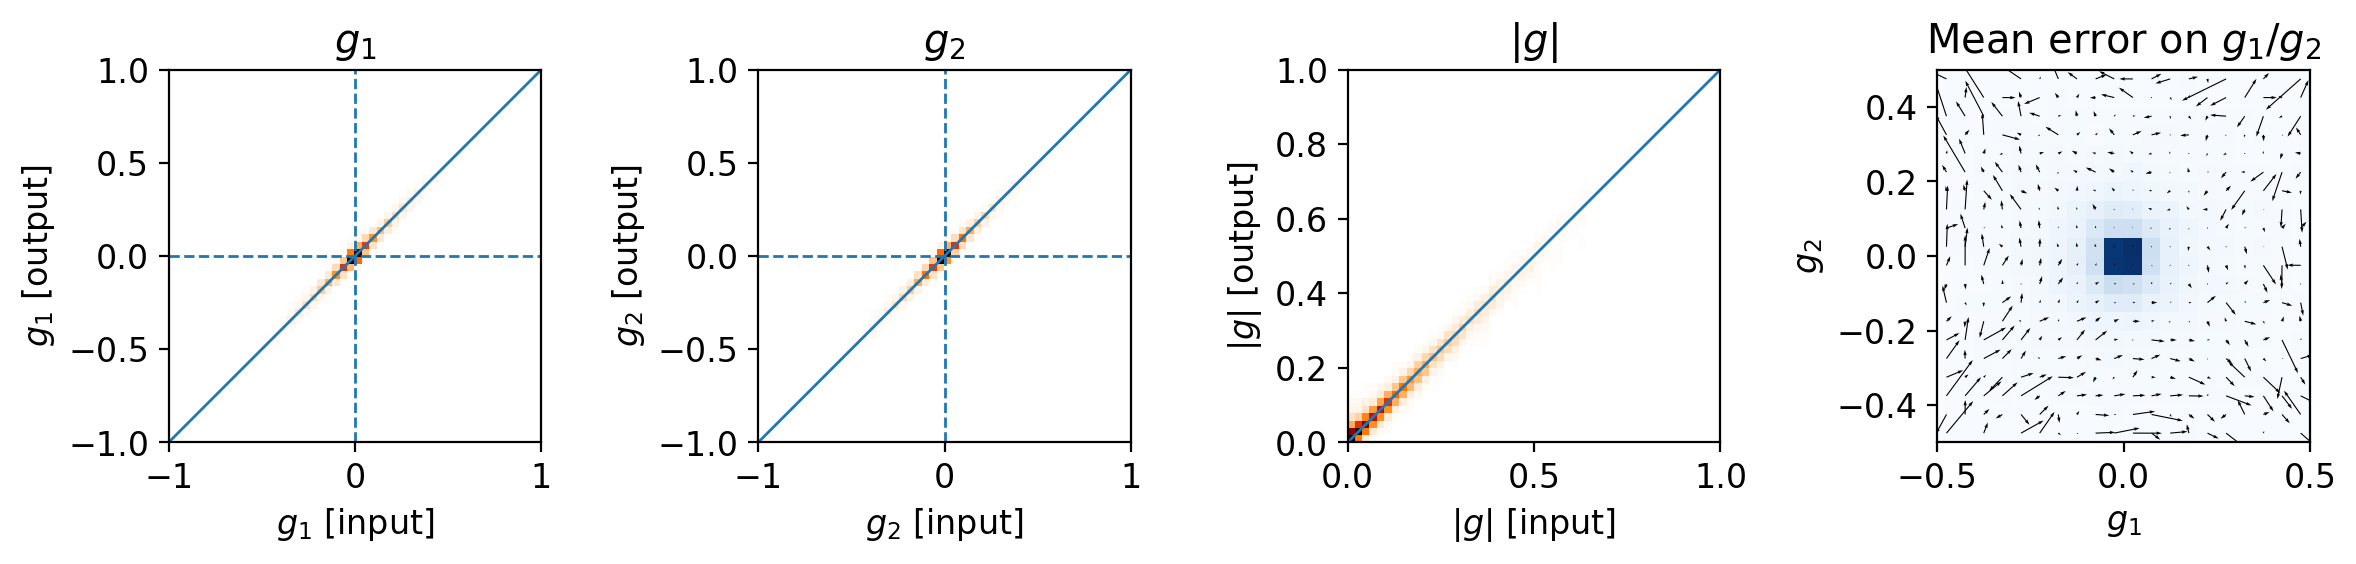

In [104]:
import scipy
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig = plt.figure(figsize=(12,5))
mpl.rcParams['font.size']=12

# Cut in SNR
#df_plot = df[df['SNR_peak']>5.]

emax = 1
bins = np.linspace(-emax,+emax,51)

ax = fig.add_subplot(141, aspect='equal')
_ = ax.hist2d(df_psf['e1_in_ksb'], df_psf['e1_out_ksb'], bins=bins, cmap=mpl.cm.gist_heat_r)
ax.plot([-emax,+emax],[-emax,+emax], lw=1)
ax.axhline(y=0, ls='--', lw=1)
ax.axvline(x=0, ls='--', lw=1)
ax.set_xlabel('$g_1$ [input]')
ax.set_ylabel('$g_1$ [output]')
ax.set_title('$g_1$')

ax = fig.add_subplot(142, aspect='equal')
_ = ax.hist2d(df_psf['e2_in_ksb'], df_psf['e2_out_ksb'], bins=bins, cmap=mpl.cm.gist_heat_r)
ax.plot([-emax,+emax],[-emax,+emax], lw=1)
ax.axhline(y=0, ls='--', lw=1)
ax.axvline(x=0, ls='--', lw=1)
ax.set_xlabel('$g_2$ [input]')
ax.set_ylabel('$g_2$ [output]')
ax.set_title('$g_2$')

ax = fig.add_subplot(143, aspect='equal')
_ = ax.hist2d(df_psf['e_in_ksb'], df_psf['e_out_ksb'], bins=np.linspace(0,1,51), cmap=mpl.cm.gist_heat_r)
#_ = ax.hist2d(df_plot['e_in'],df_plot['e_out'], bins=np.linspace(0,1,51), cmap=mpl.cm.gist_heat_r)
ax.plot([0,1],[0,1], lw=1)
ax.set_xlabel('$|g|$ [input]')
ax.set_ylabel('$|g|$ [output]')
ax.set_title('$|g|$')

emax = 0.5
ax = fig.add_subplot(144, aspect='equal')

bins = np.linspace(-emax,emax,21)
e1_in_m = scipy.stats.binned_statistic_2d(df_psf['e1_in_ksb'], df_psf['e2_in_ksb'], values=df_psf['e1_in_ksb'], bins=bins, statistic='mean').statistic
e2_in_m = scipy.stats.binned_statistic_2d(df_psf['e1_in_ksb'], df_psf['e2_in_ksb'], values=df_psf['e2_in_ksb'], bins=bins, statistic='mean').statistic
e1_out_m = scipy.stats.binned_statistic_2d(df_psf['e1_in_ksb'], df_psf['e2_in_ksb'], values=df_psf['e1_out_ksb'], bins=bins, statistic='mean').statistic
e2_out_m = scipy.stats.binned_statistic_2d(df_psf['e1_in_ksb'], df_psf['e2_in_ksb'], values=df_psf['e2_out_ksb'], bins=bins, statistic='mean').statistic

im = ax.hist2d(df_psf['e1_in_ksb'], df_psf['e2_in_ksb'], bins=bins, cmap=mpl.cm.Blues)[-1]

bins_mid = 0.5*(bins[1:]+bins[:-1])
X,Y = np.meshgrid(bins_mid, bins_mid)
ax.quiver(X,Y,e1_out_m-e1_in_m, e2_out_m-e2_in_m)

ax.set_xlabel('$g_1$')
ax.set_ylabel('$g_2$')
ax.set_xlim(bins[0],bins[-1])
ax.set_ylim(bins[0],bins[-1])

ax.set_title('Mean error on $g_1/g_2$')

plt.tight_layout()
#plt.savefig('figures/ellipticities_lsst.pdf', dpi = 300)

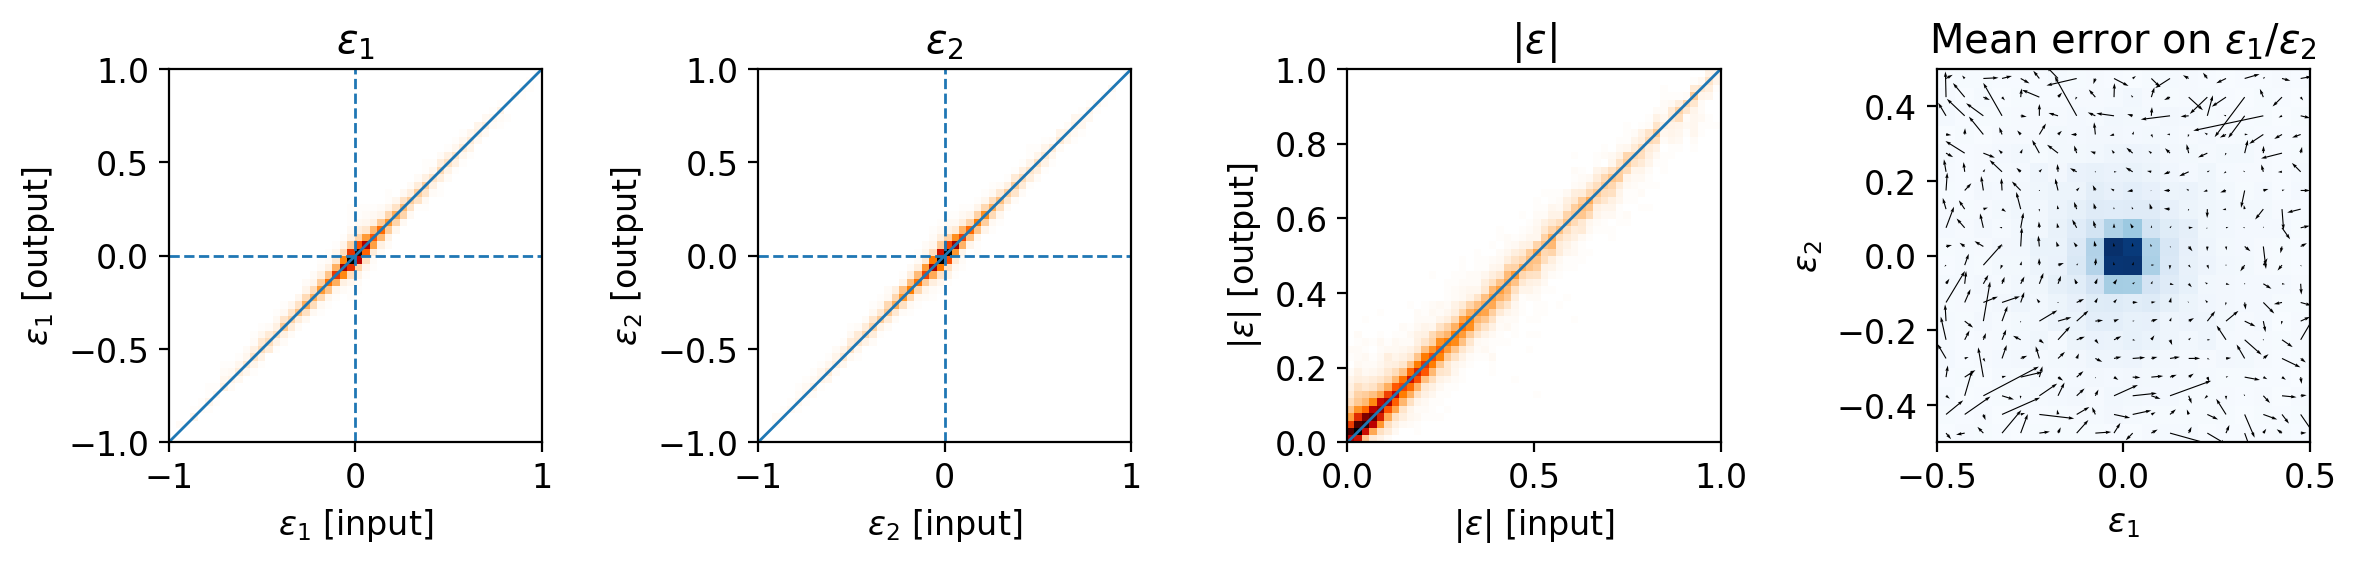

In [105]:
import scipy
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig = plt.figure(figsize=(12,5))
mpl.rcParams['font.size']=12

# Cut in SNR
#df_plot = df[df['SNR_peak']>5.]

emax = 1
bins = np.linspace(-emax,+emax,51)

ax = fig.add_subplot(141, aspect='equal')
_ = ax.hist2d(df_psf['e1_in_reg'], df_psf['e1_out_reg'], bins=bins, cmap=mpl.cm.gist_heat_r)
ax.plot([-emax,+emax],[-emax,+emax], lw=1)
ax.axhline(y=0, ls='--', lw=1)
ax.axvline(x=0, ls='--', lw=1)
ax.set_xlabel('$\epsilon_1$ [input]')
ax.set_ylabel('$\epsilon_1$ [output]')
ax.set_title('$\epsilon_1$')

ax = fig.add_subplot(142, aspect='equal')
_ = ax.hist2d(df_psf['e2_in_reg'], df_psf['e2_out_reg'], bins=bins, cmap=mpl.cm.gist_heat_r)
ax.plot([-emax,+emax],[-emax,+emax], lw=1)
ax.axhline(y=0, ls='--', lw=1)
ax.axvline(x=0, ls='--', lw=1)
ax.set_xlabel('$\epsilon_2$ [input]')
ax.set_ylabel('$\epsilon_2$ [output]')
ax.set_title('$\epsilon_2$')

ax = fig.add_subplot(143, aspect='equal')
_ = ax.hist2d(df_psf['e_in_reg'], df_psf['e_out_reg'], bins=np.linspace(0,1,51), cmap=mpl.cm.gist_heat_r)
#_ = ax.hist2d(df_plot['e_in'],df_plot['e_out'], bins=np.linspace(0,1,51), cmap=mpl.cm.gist_heat_r)
ax.plot([0,1],[0,1], lw=1)
ax.set_xlabel('$|\epsilon|$ [input]')
ax.set_ylabel('$|\epsilon|$ [output]')
ax.set_title('$|\epsilon|$')

emax = 0.5
ax = fig.add_subplot(144, aspect='equal')

bins = np.linspace(-emax,emax,21)
e1_in_m = scipy.stats.binned_statistic_2d(df_psf['e1_in_reg'], df_psf['e2_in_reg'], values=df_psf['e1_in_reg'], bins=bins, statistic='mean').statistic
e2_in_m = scipy.stats.binned_statistic_2d(df_psf['e1_in_reg'], df_psf['e2_in_reg'], values=df_psf['e2_in_reg'], bins=bins, statistic='mean').statistic
e1_out_m = scipy.stats.binned_statistic_2d(df_psf['e1_in_reg'], df_psf['e2_in_reg'], values=df_psf['e1_out_reg'], bins=bins, statistic='mean').statistic
e2_out_m = scipy.stats.binned_statistic_2d(df_psf['e1_in_reg'], df_psf['e2_in_reg'], values=df_psf['e2_out_reg'], bins=bins, statistic='mean').statistic

im = ax.hist2d(df_psf['e1_in_reg'], df_psf['e2_in_reg'], bins=bins, cmap=mpl.cm.Blues)[-1]

bins_mid = 0.5*(bins[1:]+bins[:-1])
X,Y = np.meshgrid(bins_mid, bins_mid)
ax.quiver(X,Y,e1_out_m-e1_in_m, e2_out_m-e2_in_m)

ax.set_xlabel('$\epsilon_1$')
ax.set_ylabel('$\epsilon_2$')
ax.set_xlim(bins[0],bins[-1])
ax.set_ylim(bins[0],bins[-1])

ax.set_title('Mean error on $\epsilon_1/\epsilon_2$')

plt.tight_layout()
plt.savefig('imgs/ellipticities_symmetric_v1.pdf', dpi = 300)

Text(0.5, 1.0, '$r$-band magnitude')

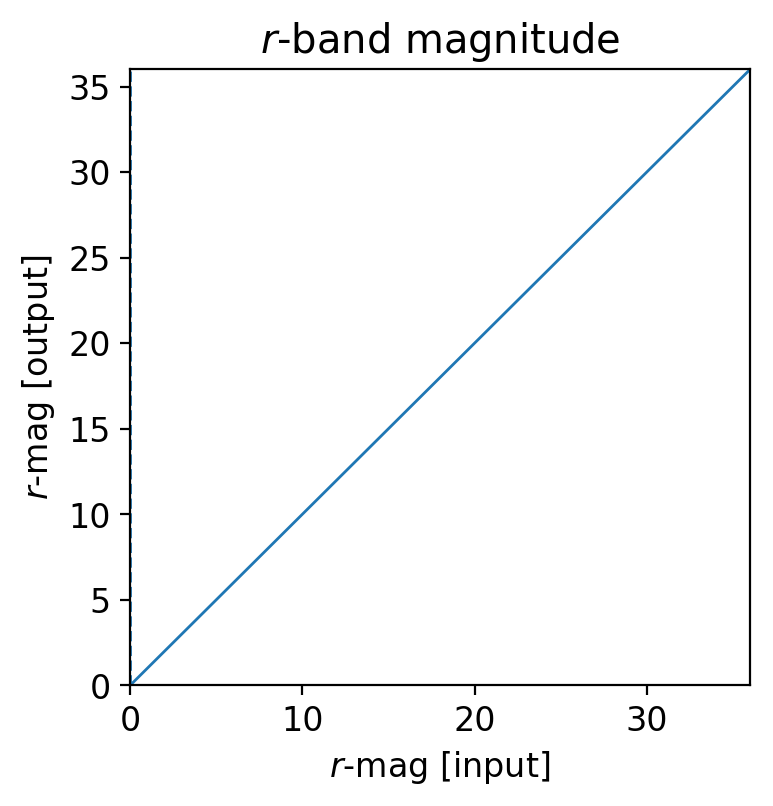

In [109]:
fig = plt.figure(figsize=(4,4))

emax = 100
bins = np.linspace(0,36,100)

#ax = fig.add_subplot(141, aspect='equal')
_ = plt.hist2d(df_psf['mag_in'], df_psf['mag_out'], bins=bins, cmap=mpl.cm.gist_heat_r)
plt.plot([-emax,+emax],[-emax,+emax], lw=1)
plt.axhline(y=0, ls='--', lw=1)
plt.axvline(x=0, ls='--', lw=1)
plt.xlabel('$r$-mag [input]')
plt.ylabel('$r$-mag [output]')
plt.title('$r$-band magnitude')

#plt.tight_layout()


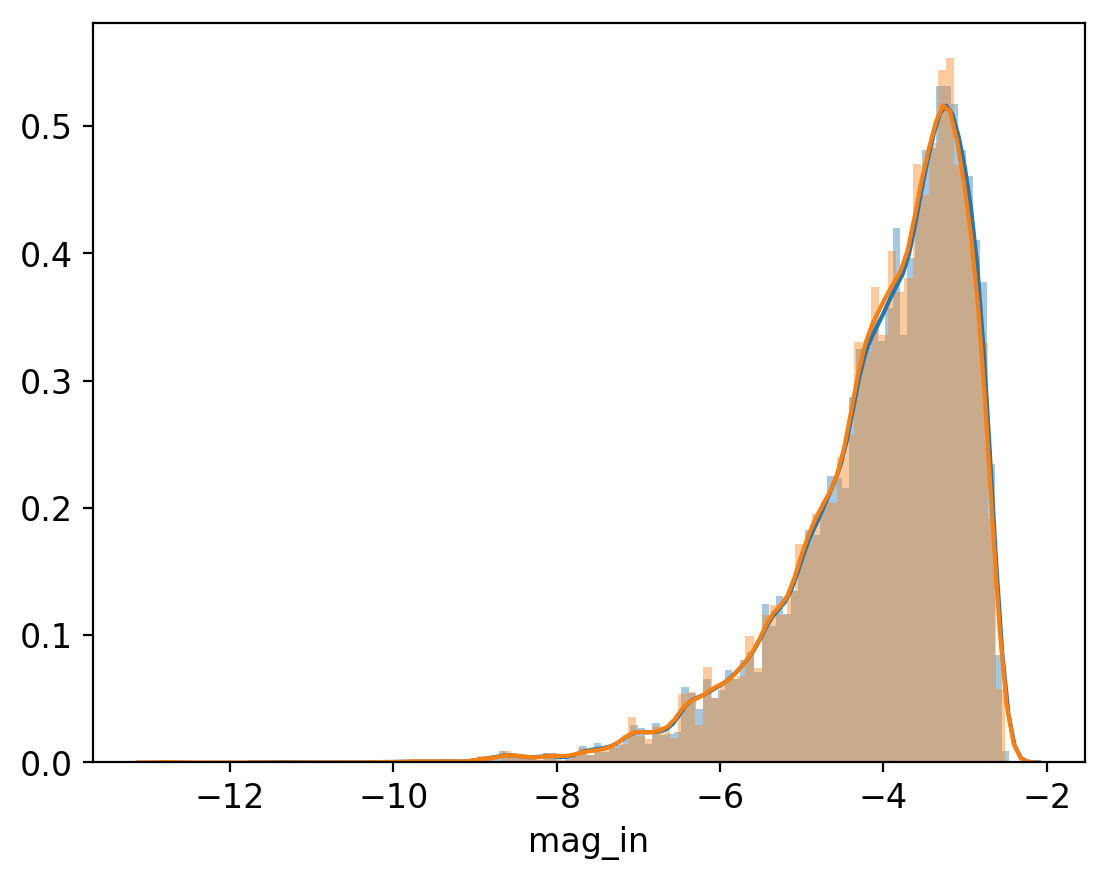

In [110]:
sns.distplot(df_psf['mag_out'], bins = 100)
sns.distplot(df_psf['mag_in'], bins = 100)

In [82]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
id                10000 non-null int64
e1                10000 non-null float64
e2                10000 non-null float64
shear_1           10000 non-null float64
shear_2           10000 non-null float64
redshift          10000 non-null float64
redshift_true     10000 non-null float64
blendedness       9999 non-null float64
snr_r             9998 non-null float64
convergence       10000 non-null float64
e1_hsm_regauss    9976 non-null float64
e2_hsm_regauss    9976 non-null float64
mag_r_meas        9998 non-null float64
mag_r_true        10000 non-null float64
dtypes: float64(13), int64(1)
memory usage: 1.1 MB


In [159]:
np.max(df_psf['mag_in']), np.max(data['mag_r_true'])

(-2.5133550086495933, 24.49972612555748)

In [160]:
df_psf['mag_in'] = df_psf['mag_in'] +( 24.49972612555748 - (-2.5133550086495933))
df_psf['mag_in'] = df_psf['mag_in'] +( 24.49972612555748 - (-2.5133550086495933))

In [161]:
np.max(data['mag_r_true'])-np.max(df_psf['mag_in'])


-27.013081134207077

## Without PSF

In [260]:
data_dir = "/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/test/"
root = 'img_noiseless'

images = np.load(root_dir+'img_noiseless_sample_2.npy', mmap_mode = 'c')
test_sample = [data_dir+'img_noiseless_sample_2.npy']

In [261]:
reload(results_processing)

<module 'tools_for_VAE.results_processing' from '../../scripts/tools_for_VAE/tools_for_VAE/results_processing.py'>

In [262]:
df_no_psf = results_processing.processing(net_no_psf,
                                         data_dir,                                           
                                         root,
                                         test_sample[0],
                                         bands_lsst,
                                         2,
                                         stamp_size, 
                                         batch_size,
                                         psf, 
                                         pix_scale_lsst)

0
1


../../scripts/tools_for_VAE/tools_for_VAE/results_processing.py:81: RuntimeWarning: invalid value encountered in arctanh
  output_vae = np.sinh(np.arctanh(network.predict([input_to_deblend,psf_images])))


2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
error for galaxy 12836
33
34
35
36
37
38
39
40
41
42
43
44
45
46
error for galaxy 18471
47
48
49
50
51
52
53
error for galaxy 21219
54
error for galaxy 21641
55
56
57
58
59
60
error for galaxy 24093
61
error for galaxy 24411
error for galaxy 24487
62
63
64
65
66
67
68
69
error for galaxy 27644
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
error for galaxy 35627
90
91
92
93
94
95
96
error for galaxy 38489
error for galaxy 38499
97
error for galaxy 38835
error for galaxy 38846
98
99

(10000, 2, 2)


In [130]:
df_no_psf.to_csv('data/df_vae_dc2_no_psf.csv')

In [ ]:
df_no_psf = pd.read_csv('data/df_vae_dc2_no_psf.csv', encoding = 'utf-8')

### Shape plots

Text(0.5, 1.0, '$|g|$')

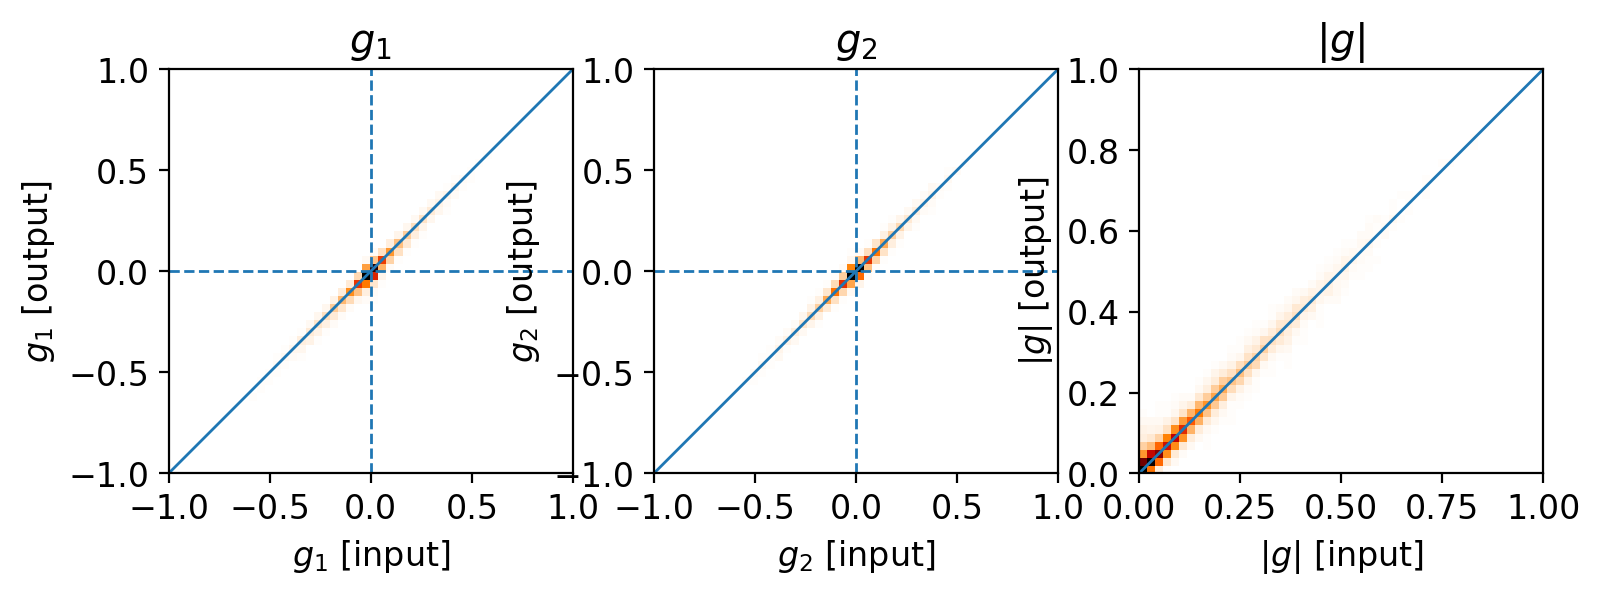

In [133]:
import scipy
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig = plt.figure(figsize=(12,5))



# Cut in SNR
#df_plot = df[df['SNR_peak']>5.]

emax = 1
bins = np.linspace(-emax,+emax,51)

ax = fig.add_subplot(141, aspect='equal')
_ = ax.hist2d(df_no_psf['e1_in_ksb'], df_no_psf['e1_out_ksb'], bins=bins, cmap=mpl.cm.gist_heat_r)
ax.plot([-emax,+emax],[-emax,+emax], lw=1)
ax.axhline(y=0, ls='--', lw=1)
ax.axvline(x=0, ls='--', lw=1)
ax.set_xlabel('$g_1$ [input]')
ax.set_ylabel('$g_1$ [output]')
ax.set_title('$g_1$')

ax = fig.add_subplot(142, aspect='equal')
_ = ax.hist2d(df_no_psf['e2_in_ksb'], df_no_psf['e2_out_ksb'], bins=bins, cmap=mpl.cm.gist_heat_r)
ax.plot([-emax,+emax],[-emax,+emax], lw=1)
ax.axhline(y=0, ls='--', lw=1)
ax.axvline(x=0, ls='--', lw=1)
ax.set_xlabel('$g_2$ [input]')
ax.set_ylabel('$g_2$ [output]')
ax.set_title('$g_2$')

ax = fig.add_subplot(143, aspect='equal')
_ = ax.hist2d(df_no_psf['e_in_ksb'], df_no_psf['e_out_ksb'], bins=np.linspace(0,1,51), cmap=mpl.cm.gist_heat_r)
#_ = ax.hist2d(df_plot['e_in'],df_plot['e_out'], bins=np.linspace(0,1,51), cmap=mpl.cm.gist_heat_r)
ax.plot([0,1],[0,1], lw=1)
ax.set_xlabel('$|g|$ [input]')
ax.set_ylabel('$|g|$ [output]')
ax.set_title('$|g|$')


Text(0.5, 1.0, '$|\\epsilon|$')

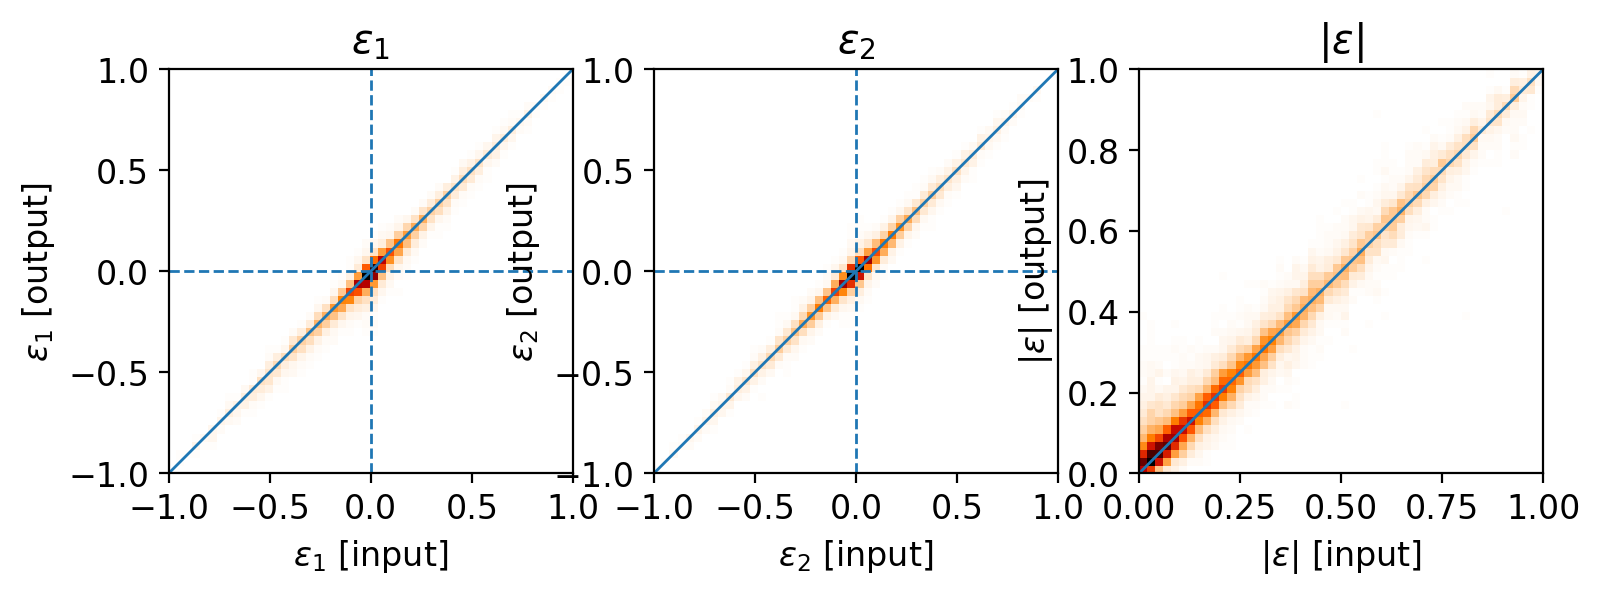

In [134]:
import scipy
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig = plt.figure(figsize=(12,5))



# Cut in SNR
#df_plot = df[df['SNR_peak']>5.]

emax = 1
bins = np.linspace(-emax,+emax,51)

ax = fig.add_subplot(141, aspect='equal')
_ = ax.hist2d(df_no_psf['e1_in_reg'], df_no_psf['e1_out_reg'], bins=bins, cmap=mpl.cm.gist_heat_r)
ax.plot([-emax,+emax],[-emax,+emax], lw=1)
ax.axhline(y=0, ls='--', lw=1)
ax.axvline(x=0, ls='--', lw=1)
ax.set_xlabel('$\epsilon_1$ [input]')
ax.set_ylabel('$\epsilon_1$ [output]')
ax.set_title('$\epsilon_1$')

ax = fig.add_subplot(142, aspect='equal')
_ = ax.hist2d(df_no_psf['e2_in_reg'], df_no_psf['e2_out_reg'], bins=bins, cmap=mpl.cm.gist_heat_r)
ax.plot([-emax,+emax],[-emax,+emax], lw=1)
ax.axhline(y=0, ls='--', lw=1)
ax.axvline(x=0, ls='--', lw=1)
ax.set_xlabel('$\epsilon_2$ [input]')
ax.set_ylabel('$\epsilon_2$ [output]')
ax.set_title('$\epsilon_2$')

ax = fig.add_subplot(143, aspect='equal')
_ = ax.hist2d(df_no_psf['e_in_reg'], df_no_psf['e_out_reg'], bins=np.linspace(0,1,51), cmap=mpl.cm.gist_heat_r)
#_ = ax.hist2d(df_plot['e_in'],df_plot['e_out'], bins=np.linspace(0,1,51), cmap=mpl.cm.gist_heat_r)
ax.plot([0,1],[0,1], lw=1)
ax.set_xlabel('$|\epsilon|$ [input]')
ax.set_ylabel('$|\epsilon|$ [output]')
ax.set_title('$|\epsilon|$')


Text(0.5, 1.0, '$r$-band magnitude')

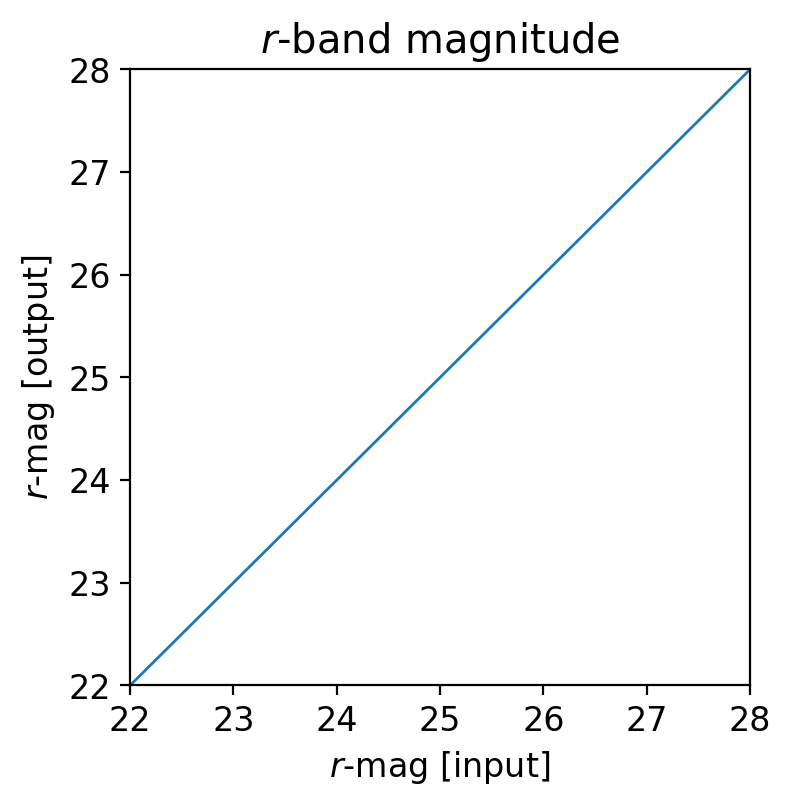

In [135]:
fig = plt.figure(figsize=(4,4))

emax = 100
bins = np.linspace(22,28,100)

#ax = fig.add_subplot(141, aspect='equal')
_ = plt.hist2d(df_no_psf['mag_in'], df_no_psf['mag_out'], bins=bins, cmap=mpl.cm.gist_heat_r)
plt.plot([-emax,+emax],[-emax,+emax], lw=1)
plt.axhline(y=0, ls='--', lw=1)
plt.axvline(x=0, ls='--', lw=1)
plt.xlabel('$r$-mag [input]')
plt.ylabel('$r$-mag [output]')
plt.title('$r$-band magnitude')

#plt.tight_layout()


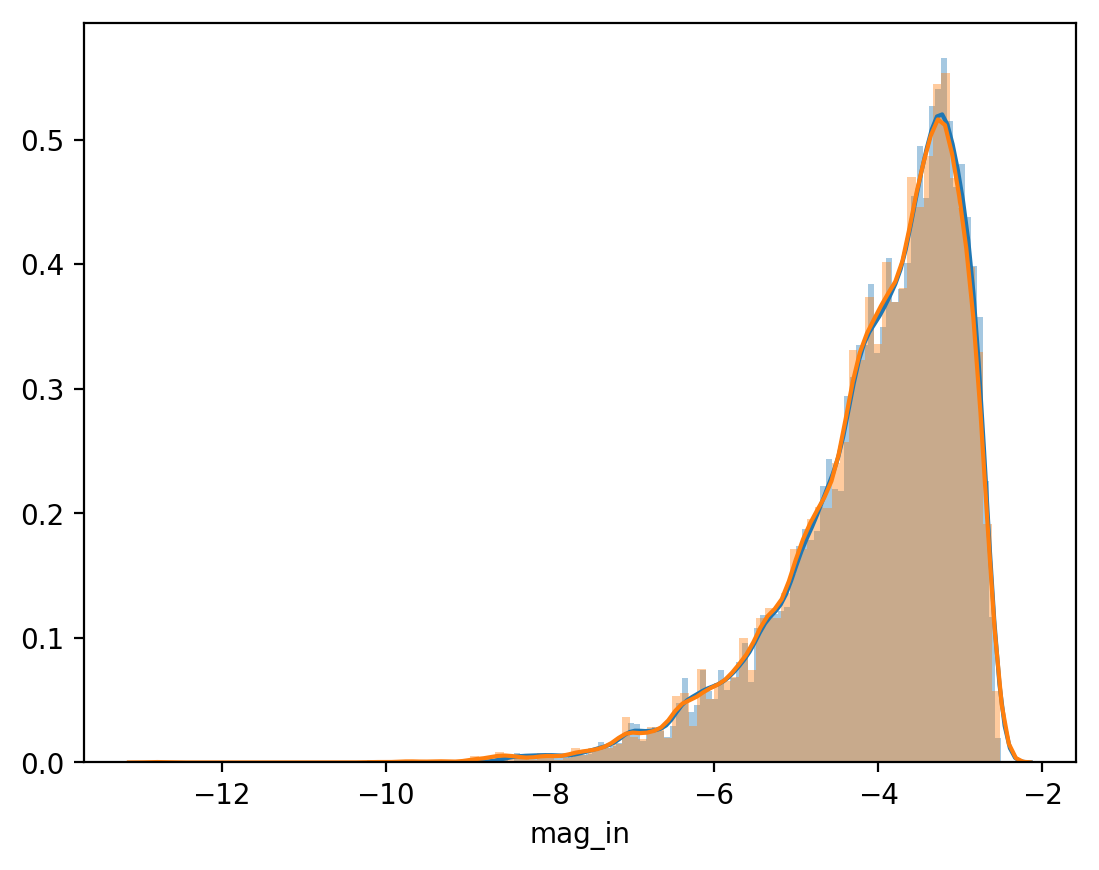

In [155]:
sns.distplot(df_no_psf['mag_out'], bins = 100)
sns.distplot(df_no_psf['mag_in'], bins = 100)

In [158]:
np.max(df_no_psf['mag_in']), np.max(data['mag_r_true'])

(24.49972612555748, 24.49972612555748)

In [157]:
df_no_psf['mag_in'] = df_no_psf['mag_in'] +( 24.49972612555748 - (-2.5133550086495933))
df_no_psf['mag_out'] = df_no_psf['mag_out'] +( 24.49972612555748 - (-2.5133550086495933))

# Delta WL parameters

## As function of SNR

In [137]:
df_psf.info(), df_no_psf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 26 columns):
Unnamed: 0         40000 non-null int64
Unnamed: 0.1       40000 non-null int64
e1_in_ksb          40000 non-null float64
e1_out_ksb         40000 non-null float64
e1_error_ksb       40000 non-null float64
e2_in_ksb          40000 non-null float64
e2_out_ksb         40000 non-null float64
e2_error_ksb       40000 non-null float64
e_in_ksb           40000 non-null float64
e_out_ksb          40000 non-null float64
e_error_ksb        40000 non-null float64
e1_in_reg          40000 non-null float64
e1_out_reg         40000 non-null float64
e1_error_reg       40000 non-null float64
e2_in_reg          40000 non-null float64
e2_out_reg         40000 non-null float64
e2_error_reg       40000 non-null float64
e_in_reg           40000 non-null float64
e_out_reg          40000 non-null float64
e_error_reg        40000 non-null float64
e_in_obs_ksb       40000 non-null float64
e_out_obs_ksb

(None, None)

In [5]:
df_plot = pd.concat([df_psf, df_no_psf], ignore_index=True, sort = True)
df_plot['exp'] = [1]*40000 + [2]*40000

In [6]:
#df_plot = df_plot.drop('Unnamed: 0', axis = 1)

In [7]:
df_plot = df_plot.dropna(axis = 1, how = 'all')

df_plot = df_plot[(df_plot['e1_out_ksb']<=1.) & 
                  (df_plot['e2_out_ksb']<=1.) &
                  (df_plot['e1_out_ksb']>=-1.) & 
                  (df_plot['e2_out_ksb']>=-1.) &
                  (df_plot['e_out_ksb']>=0.) & 
                  (df_plot['e_out_ksb']<=1.) &
                  (df_plot['mag_out']<=27.5)]

In [8]:
df_plot

,Unnamed: 0,Unnamed: 0.1,delta_mag,e1_error_ksb,e1_error_reg,e1_in_ksb,e1_in_reg,e1_out_ksb,e1_out_reg,e2_error_ksb,...,e_in_ksb,e_in_obs_ksb,e_in_reg,e_obs_error_ksb,e_out_ksb,e_out_obs_ksb,e_out_reg,mag_in,mag_out,exp
0,0,0.0,0.043663,-0.001682,-0.007393,-0.122333,-0.188693,-0.124015,-0.196086,0.022599,...,0.459852,0.434346,0.706858,-0.008725,0.438581,0.425622,0.687276,-4.417150,-4.373488,1
1,1,1.0,-0.037057,0.004917,0.010941,-0.028048,-0.065968,-0.023132,-0.055028,-0.080860,...,0.071016,0.017695,0.164745,-0.010827,0.027911,0.006869,0.065930,-2.735479,-2.772536,1
2,2,2.0,0.038406,-0.031019,-0.049480,0.345875,0.717358,0.314856,0.667878,-0.017770,...,0.371939,0.092376,0.771828,0.003729,0.336597,0.096105,0.716603,-2.628840,-2.590434,1
3,3,3.0,0.039758,-0.046279,-0.070396,0.209644,0.389945,0.163364,0.319549,-0.077501,...,0.393916,0.150599,0.736250,-0.015682,0.303679,0.134917,0.599589,-3.944892,-3.905133,1
4,4,4.0,-0.002482,-0.000724,-0.001449,0.005844,0.011909,0.005120,0.010460,-0.001534,...,0.007247,0.011476,0.014808,0.000167,0.007751,0.011643,0.015718,-3.828426,-3.830908,1
5,5,5.0,0.066499,0.001069,0.001697,-0.006214,-0.014615,-0.005145,-0.012918,-0.033196,...,0.084831,0.034829,0.189189,0.016139,0.117912,0.050968,0.260089,-2.871503,-2.805004,1
6,6,6.0,0.046813,0.043148,0.087118,0.077606,0.164632,0.120754,0.251750,-0.012866,...,0.090235,0.065432,0.191619,0.030263,0.134356,0.095695,0.280133,-3.441450,-3.394637,1
7,7,7.0,-0.007633,-0.034870,-0.069457,-0.110626,-0.233676,-0.145496,-0.303133,-0.003104,...,0.112923,0.066516,0.238520,0.019614,0.146804,0.086130,0.305804,-5.047065,-5.054697,1
8,8,8.0,0.045469,-0.020235,-0.044760,0.011039,0.023935,-0.009196,-0.020825,0.004752,...,0.045065,0.024536,0.099223,-0.004109,0.040012,0.020427,0.087458,-3.087327,-3.041857,1
9,9,9.0,0.048234,-0.021054,-0.041026,-0.115257,-0.226986,-0.136311,-0.268012,0.016712,...,0.176277,0.133259,0.347011,0.016299,0.202749,0.149558,0.397472,-4.369346,-4.321112,1


In [9]:
df_plot = df_plot.drop('Unnamed: 0', axis = 1)
df_plot = df_plot.drop('Unnamed: 0.1', axis = 1)

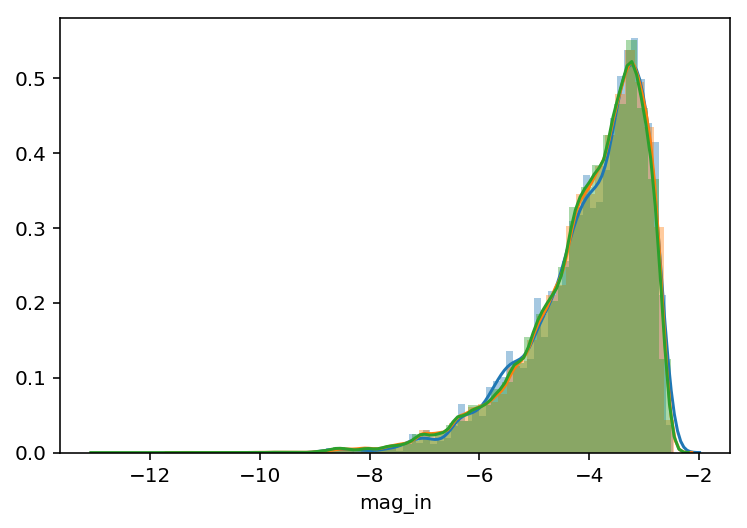

In [10]:
sns.distplot(df_plot['mag_out'][0:10000])
sns.distplot(df_plot['mag_out'][10000:])
sns.distplot(df_plot['mag_in'])

In [11]:
df_plot['mag_in'] = df_plot['mag_in'] + 27.013081134207074
df_plot['mag_out'] = df_plot['mag_out'] + 27.013081134207074

In [43]:
reload(boxplot)

<module 'tools_for_VAE.boxplot' from '../../scripts/tools_for_VAE/tools_for_VAE/boxplot.py'>

79579
[1 2]
0 1
1 2


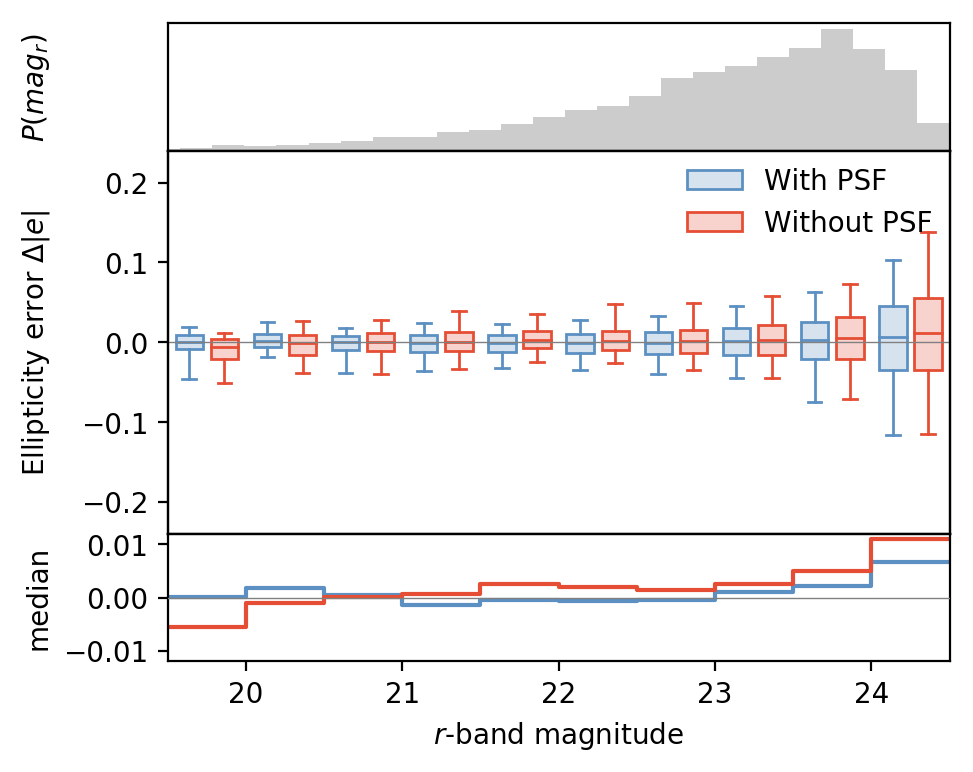

In [44]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot, 
              x = 'mag_in', y = 'e_error_ksb', z = 'exp',
              xlim = (19.5, 24.5),
              ylim = (-0.24, 0.24), 
              ylim2 = (-0.012, 0.012), 
              x_scale = 'linear',
              legend = ['With PSF', 'Without PSF'],
              x_label='$r$-band magnitude', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(mag_r)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15]),#0.35,
              nbins = 10)
fig.savefig('imgs/e_vae_mag_dc2_v1.pdf')

79579
[1 2]
0 1
1 2


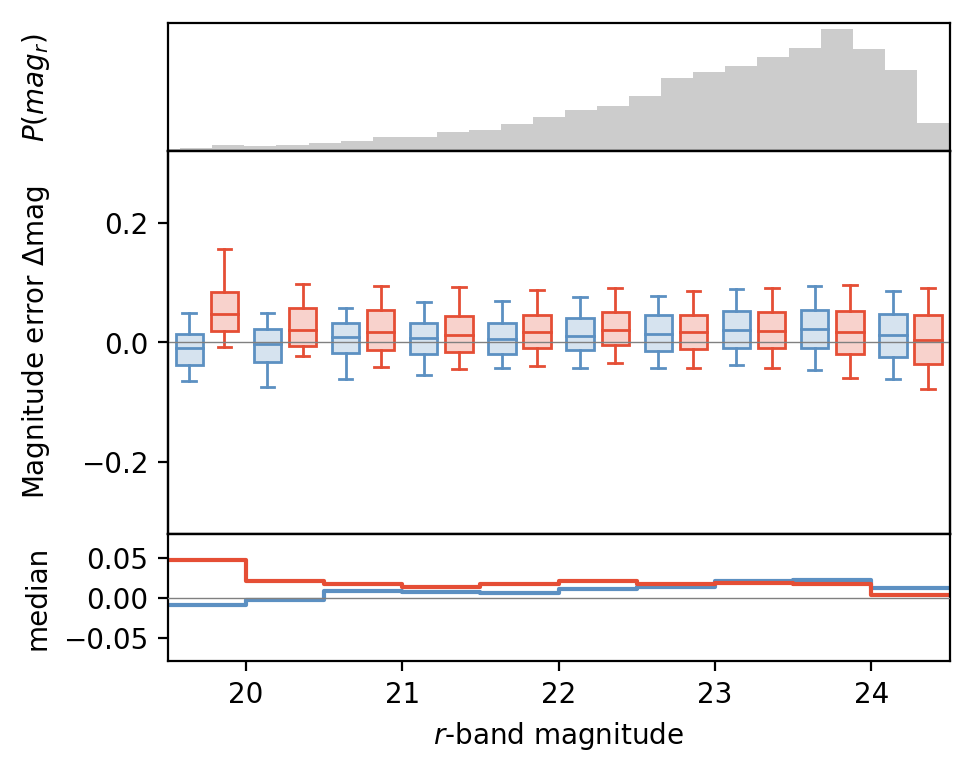

In [45]:
fig, median_mag, q1_mag, q3_mag, whislo_mag, whishi_mag = boxplot.boxplot_func(df_plot, 
              x = 'mag_in', y = 'delta_mag', z = 'exp',
              xlim = (19.5, 24.5),
              ylim = (-0.32, 0.32), 
              ylim2 = (-0.08, 0.08), 
              x_scale = 'linear',
              legend = ['With PSF', 'Without PSF'],
              x_label='$r$-band magnitude', 
              y_label = 'Magnitude error $\Delta$mag',
              y_label_hist='$P(mag_r)$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.85,0.15]),#0.35,
              nbins = 10)
fig.savefig('imgs/mag_vae_mag_dc2_v1.pdf')

79579
[1 2]
0 1
1 2


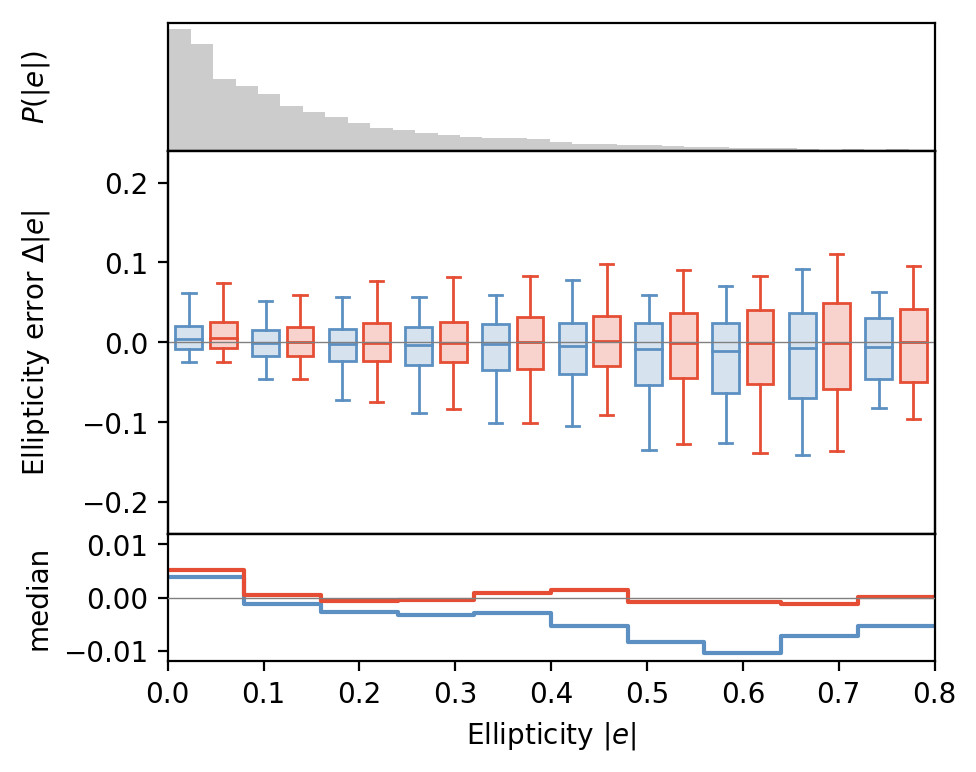

In [46]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot, 
              x = 'e_in_ksb', y = 'e_error_ksb', z = 'exp',
              xlim = (0., 0.8),
              ylim = (-0.24, 0.24), 
              ylim2 = (-0.012, 0.012), 
              x_scale = 'linear',
              legend = ['With PSF', 'Without PSF'],
              x_label='Ellipticity $|e|$', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(|e|)$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.85,0.15]),#0.35,
              nbins = 10)
fig.savefig('imgs/e_vae_e_dc2_v1.pdf')

79579
[1 2]
0 1
1 2


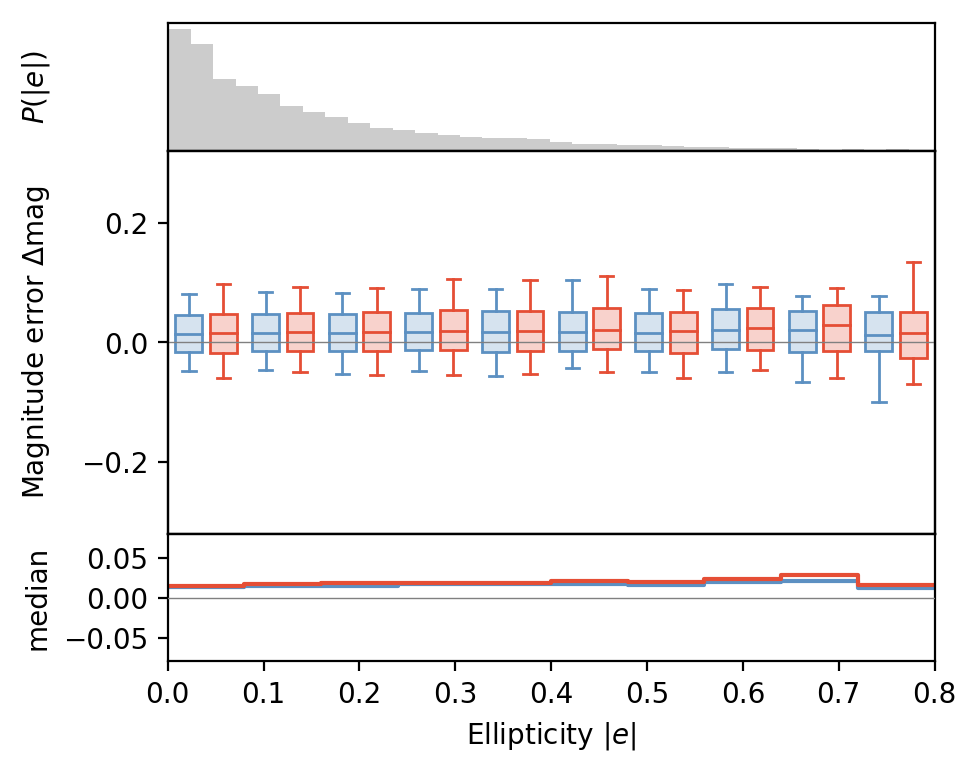

In [47]:
fig, median_mag, q1_mag, q3_mag, whislo_mag, whishi_mag = boxplot.boxplot_func(df_plot, 
              x = 'e_in_ksb', y = 'delta_mag', z = 'exp',
              xlim = (0, 0.8),
              ylim = (-0.32, 0.32), 
              ylim2 = (-0.08, 0.08), 
              x_scale = 'linear',
              legend = ['With PSF', 'Without PSF'],
              x_label='Ellipticity $|e|$', 
              y_label = 'Magnitude error $\Delta$mag',
              y_label_hist='$P(|e|)$',
              y_label_2 = 'median',
              legend_remove = True,
              palette=mpl.cm.RdYlBu([0.85,0.15]),#0.35,
              nbins = 10)
fig.savefig('imgs/mag_vae_e_dc2_v1.pdf')

In [48]:
df_stat = pd.DataFrame()
df_stat['median_shear'] = np.abs(median_shear)
df_stat['q1_shear'] = np.abs(q1_shear)
df_stat['q3_shear'] = np.abs(q3_shear)
df_stat['whislo_shear'] = np.abs(whislo_shear)
df_stat['whishi_shear'] = np.abs(whishi_shear)
df_stat['median_mag'] = np.abs(median_mag)
df_stat['q1_mag'] = np.abs(q1_mag)
df_stat['q3_mag'] = np.abs(q3_mag)
df_stat['whislo_mag'] = np.abs(whislo_mag)
df_stat['whishi_mag'] = np.abs(whishi_mag)
df_stat['stats_names'] = ['PSF']*10 + ['No PSF']*10

x = 10

In [49]:
x = 10 # for the first x bins

In [216]:
df_stat

,median_shear,q1_shear,q3_shear,whislo_shear,whishi_shear,median_mag,q1_mag,q3_mag,whislo_mag,whishi_mag,stats_names
0,0.001244,0.027003,0.032172,0.072243,0.090452,0.001244,0.027003,0.032172,0.072243,0.090452,PSF
1,0.006980,0.038576,0.019635,0.066738,0.048953,0.006980,0.038576,0.019635,0.066738,0.048953,PSF
2,0.005830,0.024785,0.029142,0.069001,0.062592,0.005830,0.024785,0.029142,0.069001,0.062592,PSF
3,0.008099,0.019082,0.033110,0.061564,0.055472,0.008099,0.019082,0.033110,0.061564,0.055472,PSF
4,0.005681,0.020288,0.029489,0.046968,0.067067,0.005681,0.020288,0.029489,0.046968,0.067067,PSF
5,0.009361,0.015239,0.037702,0.042562,0.071787,0.009361,0.015239,0.037702,0.042562,0.071787,PSF
6,0.012109,0.014866,0.043024,0.044501,0.075277,0.012109,0.014866,0.043024,0.044501,0.075277,PSF
7,0.018957,0.010943,0.050504,0.038030,0.084937,0.018957,0.010943,0.050504,0.038030,0.084937,PSF
8,0.022036,0.008996,0.053269,0.044847,0.092907,0.022036,0.008996,0.053269,0.044847,0.092907,PSF
9,0.013897,0.022015,0.048893,0.061610,0.087766,0.013897,0.022015,0.048893,0.061610,0.087766,PSF


In [64]:
param = 'median_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x]), np.mean(df_stat[param][20:20+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][:x])/np.mean(df_stat[param][10:10+x]) , np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][20:20+x])]))

mean for each exp: [0.005239382567268072, 0.004107478169898862, nan]
improvement between each exp: [1.2755716160987123, nan]


In [65]:
param = 'q1_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x]), np.mean(df_stat[param][20:20+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][:x])/np.mean(df_stat[param][10:10+x]) , np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][20:20+x])]))

mean for each exp: [0.04681409682481458, 0.014540351125629014, nan]
improvement between each exp: [3.219598785499714, nan]


In [66]:
param = 'q3_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x]), np.mean(df_stat[param][20:20+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][:x])/np.mean(df_stat[param][10:10+x]) , np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][20:20+x])]))

mean for each exp: [0.03228578070345052, 0.035582130219984374, nan]
improvement between each exp: [0.9073594105761973, nan]


In [67]:
param = 'whislo_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x]), np.mean(df_stat[param][20:20+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][:x])/np.mean(df_stat[param][10:10+x]) , np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][20:20+x])]))

mean for each exp: [0.11210667405661459, 0.0438889209904926, nan]
improvement between each exp: [2.5543274139936045, nan]


In [68]:
param = 'whishi_shear'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x]), np.mean(df_stat[param][20:20+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][:x])/np.mean(df_stat[param][10:10+x]) , np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][20:20+x])]))

mean for each exp: [0.09452648240481572, 0.10825622555743106, nan]
improvement between each exp: [0.8731736389115878, nan]


In [69]:
param = 'median_mag'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x]), np.mean(df_stat[param][20:20+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][:x])/np.mean(df_stat[param][10:10+x]) , np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][20:20+x])]))

mean for each exp: [0.005197449106237428, 0.00522542481893975, nan]
improvement between each exp: [0.9946462319004337, nan]


In [70]:
param = 'q1_mag'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x]), np.mean(df_stat[param][20:20+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][:x])/np.mean(df_stat[param][10:10+x]) , np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][20:20+x])]))

mean for each exp: [0.03709116057929573, 0.03650556938424392, nan]
improvement between each exp: [1.0160411467326558, nan]


In [71]:
param = 'q3_mag'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x]), np.mean(df_stat[param][20:20+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][:x])/np.mean(df_stat[param][10:10+x]) , np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][20:20+x])]))

mean for each exp: [0.03757126844632984, 0.02764753443340818, nan]
improvement between each exp: [1.358937395912245, nan]


In [72]:
param = 'whislo_mag'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x]), np.mean(df_stat[param][20:20+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][:x])/np.mean(df_stat[param][10:10+x]) , np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][20:20+x])]))

mean for each exp: [0.08030948094582194, 0.07770806893107682, nan]
improvement between each exp: [1.0334767296437701, nan]


In [73]:
param = 'whishi_mag'
print('mean for each exp: '+str([np.mean(df_stat[param][:x]), np.mean(df_stat[param][10:10+x]), np.mean(df_stat[param][20:20+x])]))
print('improvement between each exp: '+str([np.mean(df_stat[param][:x])/np.mean(df_stat[param][10:10+x]) , np.mean(df_stat[param][10:10+x])/np.mean(df_stat[param][20:20+x])]))

mean for each exp: [0.08056040296296559, 0.06950827363623446, nan]
improvement between each exp: [1.1590045148376362, nan]


## PSF changed

### With PSF

In [300]:
reload(results_processing)

<module 'tools_for_VAE.results_processing' from '../../scripts/tools_for_VAE/tools_for_VAE/results_processing.py'>

In [21]:
data_dir = "/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/test/"
root = 'img_noiseless'

images = np.load(root_dir+'psf_diff_non_sheared_images.npy', mmap_mode = 'c')
test_sample = [data_dir+'psf_diff_non_sheared_images.npy']
psf_sheared = np.load(root_dir+'psf_diff_non_sheared_PSF.npy', mmap_mode = 'c')

In [16]:
images.shape, psf_sheared.shape

((5000, 59, 59, 6), (5000, 59, 59, 6))

In [17]:
df_psf_sheared = results_processing.processing_sheared_psf(net_psf,
                                     data_dir,                                           
                                     root,
                                     test_sample[0],
                                     bands_lsst,
                                     2,
                                     stamp_size, 
                                     batch_size,
                                     psf_sheared, 
                                     pix_scale_lsst,
                                     case = 0)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49

(5000, 2, 2)


Text(0.5, 1.0, '$|\\epsilon|$')

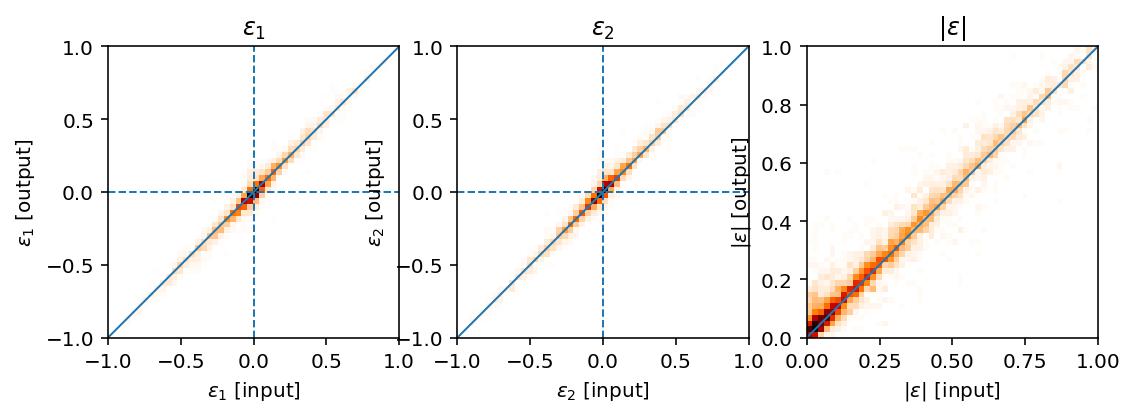

In [18]:
import scipy
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig = plt.figure(figsize=(12,5))

emax = 1
bins = np.linspace(-emax,+emax,51)

ax = fig.add_subplot(141, aspect='equal')
_ = ax.hist2d(df_psf_sheared['e1_in_reg'], df_psf_sheared['e1_out_reg'], bins=bins, cmap=mpl.cm.gist_heat_r)
ax.plot([-emax,+emax],[-emax,+emax], lw=1)
ax.axhline(y=0, ls='--', lw=1)
ax.axvline(x=0, ls='--', lw=1)
ax.set_xlabel('$\epsilon_1$ [input]')
ax.set_ylabel('$\epsilon_1$ [output]')
ax.set_title('$\epsilon_1$')

ax = fig.add_subplot(142, aspect='equal')
_ = ax.hist2d(df_psf_sheared['e2_in_reg'], df_psf_sheared['e2_out_reg'], bins=bins, cmap=mpl.cm.gist_heat_r)
ax.plot([-emax,+emax],[-emax,+emax], lw=1)
ax.axhline(y=0, ls='--', lw=1)
ax.axvline(x=0, ls='--', lw=1)
ax.set_xlabel('$\epsilon_2$ [input]')
ax.set_ylabel('$\epsilon_2$ [output]')
ax.set_title('$\epsilon_2$')

ax = fig.add_subplot(143, aspect='equal')
_ = ax.hist2d(df_psf_sheared['e_in_reg'], df_psf_sheared['e_out_reg'], bins=np.linspace(0,1,51), cmap=mpl.cm.gist_heat_r)
#_ = ax.hist2d(df_plot['e_in'],df_plot['e_out'], bins=np.linspace(0,1,51), cmap=mpl.cm.gist_heat_r)
ax.plot([0,1],[0,1], lw=1)
ax.set_xlabel('$|\epsilon|$ [input]')
ax.set_ylabel('$|\epsilon|$ [output]')
ax.set_title('$|\epsilon|$')


In [19]:
reload(results_processing)

<module 'tools_for_VAE.results_processing' from '../../scripts/tools_for_VAE/tools_for_VAE/results_processing.py'>

In [20]:
data_dir = "/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/test/"
root = 'img_noiseless'

#images = np.load(root_dir+'psf_diff_non_shear_images.npy', mmap_mode = 'c')
#test_sample = [data_dir+'psf_diff_non_shear_images.npy']
#psf_sheared = np.load(root_dir+'psf_diff_non_shear_PSF.npy', mmap_mode = 'c')


images = np.load(root_dir+'img_noiseless_sample_2.npy', mmap_mode = 'c')
test_sample = [data_dir+'img_noiseless_sample_2.npy']

In [291]:
df_psf_2 = results_processing.processing_sheared_psf(net_psf,
                                     data_dir,                                           
                                     root,
                                     test_sample[0],
                                     bands_lsst,
                                     2,
                                     stamp_size, 
                                     batch_size,
                                     psf, 
                                     pix_scale_lsst,
                                     case = 0)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99

(10000, 2, 2)


### Without PSF

In [22]:
df_no_psf_sheared = results_processing.processing_sheared_psf(net_no_psf,
                                     data_dir,                                           
                                     root,
                                     test_sample[0],
                                     bands_lsst,
                                     2,
                                     stamp_size, 
                                     batch_size,
                                     psf_sheared, 
                                     pix_scale_lsst,
                                     case = 2)

0
1


../../scripts/tools_for_VAE/tools_for_VAE/results_processing.py:230: RuntimeWarning: invalid value encountered in arctanh
  output_vae = np.sinh(np.arctanh(network.predict([input_to_deblend,psf_images])))


2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
error for galaxy 12836
33
34
35
36
37
38
39
40
41
42
43
44
45
46
error for galaxy 18471
47
48
49

(5000, 2, 2)


Text(0.5, 1.0, '$|\\epsilon|$')

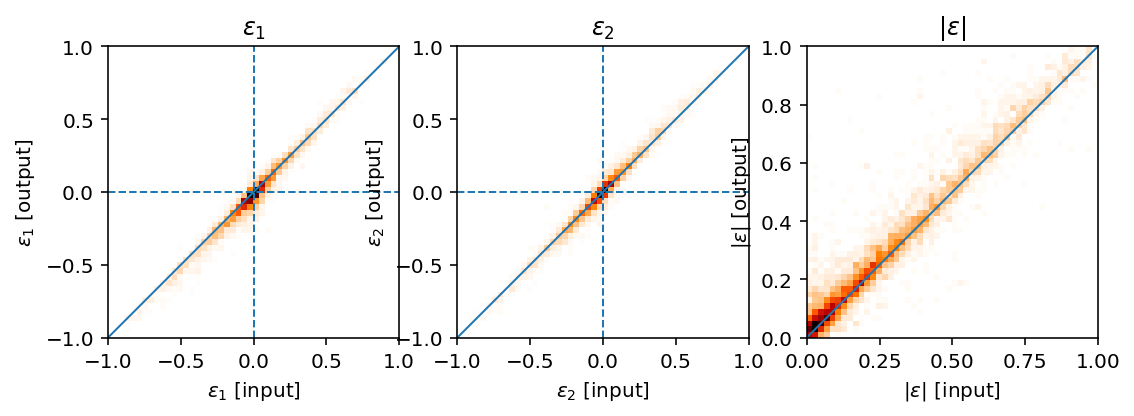

In [23]:
import scipy
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig = plt.figure(figsize=(12,5))

emax = 1
bins = np.linspace(-emax,+emax,51)

ax = fig.add_subplot(141, aspect='equal')
_ = ax.hist2d(df_no_psf_sheared['e1_in_reg'], df_no_psf_sheared['e1_out_reg'], bins=bins, cmap=mpl.cm.gist_heat_r)
ax.plot([-emax,+emax],[-emax,+emax], lw=1)
ax.axhline(y=0, ls='--', lw=1)
ax.axvline(x=0, ls='--', lw=1)
ax.set_xlabel('$\epsilon_1$ [input]')
ax.set_ylabel('$\epsilon_1$ [output]')
ax.set_title('$\epsilon_1$')

ax = fig.add_subplot(142, aspect='equal')
_ = ax.hist2d(df_no_psf_sheared['e2_in_reg'], df_no_psf_sheared['e2_out_reg'], bins=bins, cmap=mpl.cm.gist_heat_r)
ax.plot([-emax,+emax],[-emax,+emax], lw=1)
ax.axhline(y=0, ls='--', lw=1)
ax.axvline(x=0, ls='--', lw=1)
ax.set_xlabel('$\epsilon_2$ [input]')
ax.set_ylabel('$\epsilon_2$ [output]')
ax.set_title('$\epsilon_2$')

ax = fig.add_subplot(143, aspect='equal')
_ = ax.hist2d(df_no_psf_sheared['e_in_reg'], df_no_psf_sheared['e_out_reg'], bins=np.linspace(0,1,51), cmap=mpl.cm.gist_heat_r)
#_ = ax.hist2d(df_plot['e_in'],df_plot['e_out'], bins=np.linspace(0,1,51), cmap=mpl.cm.gist_heat_r)
ax.plot([0,1],[0,1], lw=1)
ax.set_xlabel('$|\epsilon|$ [input]')
ax.set_ylabel('$|\epsilon|$ [output]')
ax.set_title('$|\epsilon|$')


### Comparison with different PSF

#### Net with PSF

In [33]:
df_psf['mag_in']=df_psf['mag_in']+27.013081134207074

In [34]:
df_psf_small = df_psf.copy()[:5000]

In [35]:
df_plot = pd.concat([df_psf_small, df_psf_sheared], ignore_index=True, sort = True)
df_plot['exp'] = [1]*5000 + [2]*5000

In [36]:
#df_plot = df_plot.dropna(axis = 1, how = 'all')

df_plot = df_plot[(df_plot['e1_out_ksb']<=1.) & 
                  (df_plot['e2_out_ksb']<=1.) &
                  (df_plot['e1_out_ksb']>=-1.) & 
                  (df_plot['e2_out_ksb']>=-1.) &
                  (df_plot['e_out_ksb']>=0.) & 
                  (df_plot['e_out_ksb']<=1.) &
                  (df_plot['mag_out']<=27.5)]

#df_plot = df_plot.drop('Unnamed: 0', axis = 1)
#df_plot = df_plot.drop('Unnamed: 0.1', axis = 1)

In [37]:
df_plot_cropped = pd.DataFrame()

df_plot_cropped['mag_in'] = df_plot['mag_in']
df_plot_cropped['e_error_ksb'] = df_plot['e_error_ksb']
df_plot_cropped['exp'] = df_plot['exp']

In [38]:
df_plot_cropped

,mag_in,e_error_ksb,exp
0,22.595931,-0.021271,1
1,24.277602,-0.043105,1
2,24.384241,-0.035341,1
3,23.068190,-0.090237,1
4,23.184655,0.000504,1
5,24.141578,0.033081,1
6,23.571631,0.044120,1
7,21.966016,0.033881,1
8,23.925755,-0.005053,1
9,22.643735,0.026472,1


9963
[1 2]
0 1
1 2


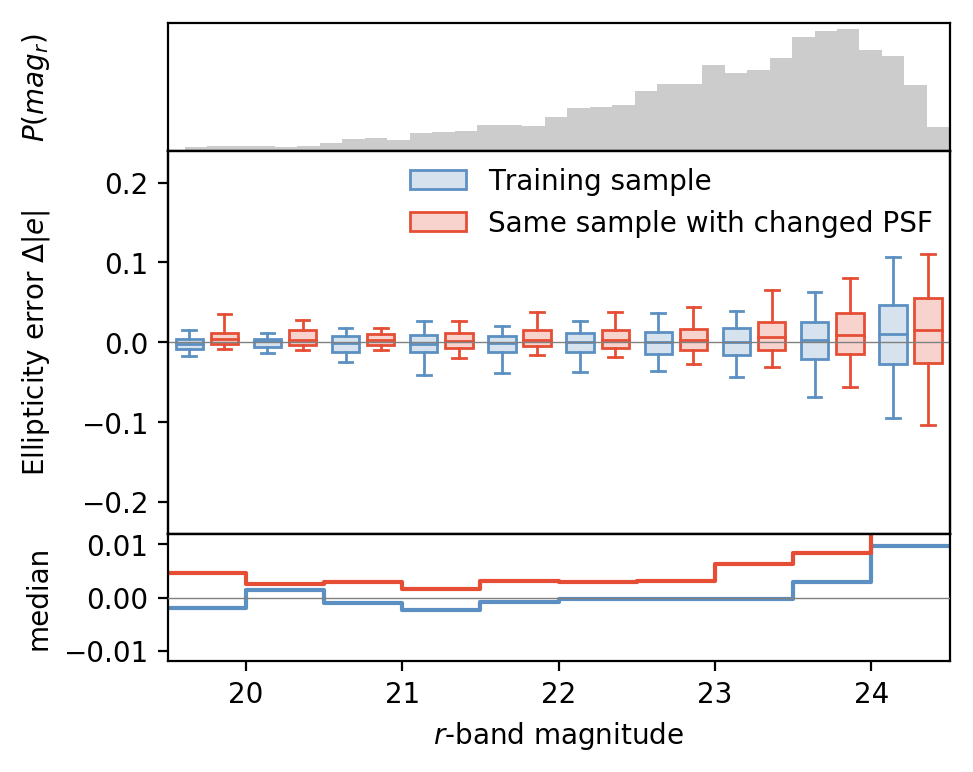

In [39]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_cropped, 
              x = 'mag_in', y = 'e_error_ksb', z = 'exp',
              xlim = (19.5, 24.5),
              ylim = (-0.24, 0.24), 
              ylim2 = (-0.012, 0.012), 
              x_scale = 'linear',
              legend = ['Training sample', 'Same sample with changed PSF'],
              x_label='$r$-band magnitude', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(mag_r)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15]),#0.35,
              nbins = 10)
#fig.savefig('imgs/e_vae_mag_dc2_v1.pdf')

#### Net without PSF

In [40]:
df_no_psf['mag_in']=df_no_psf['mag_in']+27.013081134207074

In [41]:
df_no_psf_small = df_no_psf.copy()[:5000]

In [42]:
df_plot = pd.concat([df_no_psf_small, df_no_psf_sheared], ignore_index=True, sort = True)
df_plot['exp'] = [1]*5000 + [2]*5000

In [43]:
df_plot = df_plot.dropna(axis = 1, how = 'all')

df_plot = df_plot[(df_plot['e1_out_ksb']<=1.) & 
                  (df_plot['e2_out_ksb']<=1.) &
                  (df_plot['e1_out_ksb']>=-1.) & 
                  (df_plot['e2_out_ksb']>=-1.) &
                  (df_plot['e_out_ksb']>=0.) & 
                  (df_plot['e_out_ksb']<=1.) &
                  (df_plot['mag_out']<=27.5)]

#df_plot = df_plot.drop('Unnamed: 0', axis = 1)

In [44]:
df_plot_cropped = pd.DataFrame()

df_plot_cropped['mag_in'] = df_plot['mag_in']
df_plot_cropped['e_error_ksb'] = df_plot['e_error_ksb']
df_plot_cropped['exp'] = df_plot['exp']

9959
[1 2]
0 1
1 2


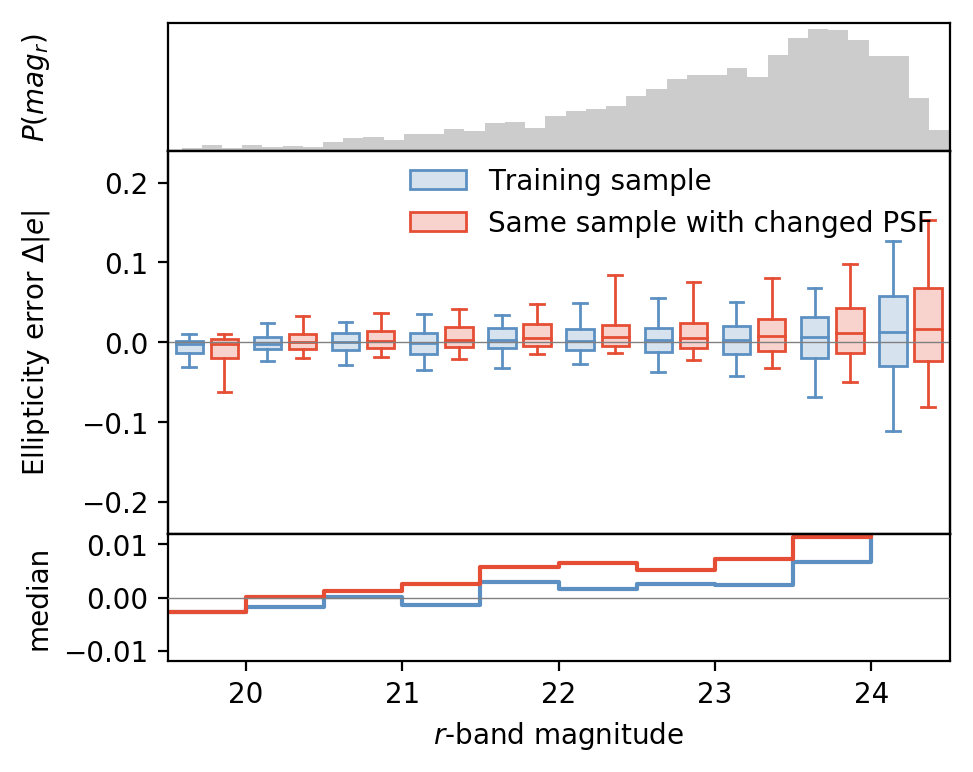

In [45]:
fig, median_shear, q1_shear, q3_shear, whislo_shear, whishi_shear = boxplot.boxplot_func(df_plot_cropped, 
              x = 'mag_in', y = 'e_error_ksb', z = 'exp',
              xlim = (19.5, 24.5),
              ylim = (-0.24, 0.24), 
              ylim2 = (-0.012, 0.012), 
              x_scale = 'linear',
              legend = ['Training sample', 'Same sample with changed PSF'],
              x_label='$r$-band magnitude', 
              y_label = 'Ellipticity error $\\Delta |e|$',
              y_label_hist='$P(mag_r)$',
              y_label_2 = 'median',
              legend_remove = False,
              palette=mpl.cm.RdYlBu([0.85,0.15]),#0.35,
              nbins = 10)
#fig.savefig('imgs/e_vae_mag_dc2_v1.pdf')

## Shear Bias 

As function of SNR

In [46]:
df_bias = pd.DataFrame()
param = 'SNR'
#df_test = df_lsst_euclid[(df_lsst_euclid['e1_out']<=1.) & (df_lsst_euclid['e2_out']<=1.)]

bins = np.geomspace(30, 3000, 10)

for k in range (2):
    slope = []
    intercept = []
    std_err = []
    bins_list = []

    bining_temp = 10
    mask = ~np.isnan(df_lsst['e_in']) & ~np.isnan(df_lsst['e_out'])
    for i, bining in enumerate (bins):
        df_test = df_lsst[(df_lsst['e1_out']<=1.) & 
                          (df_lsst['e2_out']<=1.) &
                          (df_lsst['e_out']<=1.) & 
                          (df_lsst['e_out']>=0.) &
                          (bining_temp <= df_lsst[param]) &
                          (df_lsst[param]<= bining)]
        slope.append(stats.linregress(df_test['e'+str(k+1)+'_in'][mask], df_test['e'+str(k+1)+'_out'][mask])[0]-1)
        intercept.append(stats.linregress(df_test['e'+str(k+1)+'_in'][mask], df_test['e'+str(k+1)+'_out'][mask])[1])
        std_err.append(stats.linregress(df_test['e'+str(k+1)+'_in'][mask], df_test['e'+str(k+1)+'_out'][mask])[4])
        bins_list.append(bining)#-(bins[0]/2)
        bining_temp = bining

    bining_temp = 10
    mask = ~np.isnan(df_lsst_euclid['e_in']) & ~np.isnan(df_lsst_euclid['e_out'])
    for i, bining in enumerate (bins):
        df_test = df_lsst_euclid[(df_lsst_euclid['e1_out']<=1.) & 
                                 (df_lsst_euclid['e2_out']<=1.) &
                                 (df_lsst_euclid['e_out']<=1.) & 
                                 (df_lsst_euclid['e_out']>=0.) &
                                 (bining_temp <= df_lsst_euclid[param]) &
                                 (df_lsst_euclid[param]<= bining)]
        slope.append(stats.linregress(df_test['e'+str(k+1)+'_in'][mask], df_test['e'+str(k+1)+'_out'][mask])[0]-1)
        intercept.append(stats.linregress(df_test['e'+str(k+1)+'_in'][mask], df_test['e'+str(k+1)+'_out'][mask])[1])
        std_err.append(stats.linregress(df_test['e'+str(k+1)+'_in'][mask], df_test['e'+str(k+1)+'_out'][mask])[4])
        bins_list.append(bining)#-(bins[0]/2)
        bining_temp = bining

    df_bias['slope_e'+str(k+1)] = np.array(slope)
    df_bias['intercept_e'+str(k+1)] = np.array(intercept)
    df_bias['std_err_e'+str(k+1)] = np.array(std_err)

In [47]:
list_mid_bins = []
idx_temp = 10
for i, idx in enumerate (bins_list):
    if i == 10:
        idx_temp = 10
    list_mid_bins.append(idx - (idx - idx_temp)/2)
    idx_temp = idx

In [48]:
list_mid_bins, bins_list, 

([20.0,
  40.02150805800087,
  66.75989909110773,
  111.36222353729855,
  185.76338490636067,
  309.87200215440146,
  516.897653257015,
  862.2372530754765,
  1438.2984250491058,
  2399.2263754784126,
  20.0,
  40.02150805800087,
  66.75989909110773,
  111.36222353729855,
  185.76338490636067,
  309.87200215440146,
  516.897653257015,
  862.2372530754765,
  1438.2984250491058,
  2399.2263754784126],
 [29.999999999999996,
  50.043016116001745,
  83.47678206621372,
  139.24766500838336,
  232.27910480433795,
  387.46489950446494,
  646.330407009565,
  1078.144099141388,
  1798.4527509568234,
  3000.0000000000014,
  29.999999999999996,
  50.043016116001745,
  83.47678206621372,
  139.24766500838336,
  232.27910480433795,
  387.46489950446494,
  646.330407009565,
  1078.144099141388,
  1798.4527509568234,
  3000.0000000000014])

In [49]:
df_bias['Experience'] = len(bins)*['LSST'] + len(bins)*['LSST+Euclid']
df_bias['bins_list'] = list_mid_bins
df_bias['mean_g'] = np.mean([df_bias['slope_e1'],df_bias['slope_e2']], axis = 0)
df_bias['mean_stderr'] = np.mean([df_bias['std_err_e1'],df_bias['std_err_e2']], axis = 0)

In [50]:
df_bias

,slope_e1,intercept_e1,std_err_e1,slope_e2,intercept_e2,std_err_e2,Experience,bins_list,mean_g,mean_stderr
0,-0.116480,0.000077,0.006417,-0.121544,0.003436,0.006773,LSST,20.000000,-0.119012,0.006595
1,-0.112146,-0.002609,0.004895,-0.111593,0.002803,0.005109,LSST,40.021508,-0.111870,0.005002
2,-0.064557,-0.000798,0.004175,-0.070514,0.000662,0.003974,LSST,66.759899,-0.067535,0.004074
3,-0.052540,-0.001557,0.003422,-0.055240,0.000017,0.003547,LSST,111.362224,-0.053890,0.003484
4,-0.022863,-0.002522,0.003998,-0.016510,0.001979,0.004259,LSST,185.763385,-0.019687,0.004128
5,-0.003534,-0.000714,0.003185,-0.005602,0.002267,0.003340,LSST,309.872002,-0.004568,0.003262
6,0.002632,-0.000366,0.003264,0.011782,0.002860,0.003889,LSST,516.897653,0.007207,0.003576
7,0.028325,0.000152,0.007507,0.019040,0.004275,0.005255,LSST,862.237253,0.023683,0.006381
8,0.041847,0.003106,0.009758,0.026100,-0.002526,0.011006,LSST,1438.298425,0.033973,0.010382
9,0.000855,-0.005864,0.030557,-0.016190,0.001867,0.025982,LSST,2399.226375,-0.007668,0.028269


["['LSST $|g_1|$', 'LSST+Euclid $|g_1|$']", 'Experience', 'LSST', 'LSST+Euclid']
["['LSST $|g_2|$', 'LSST+Euclid $|g_2|$']", 'Experience', 'LSST', 'LSST+Euclid']
['Experience', 'LSST', 'LSST+Euclid']


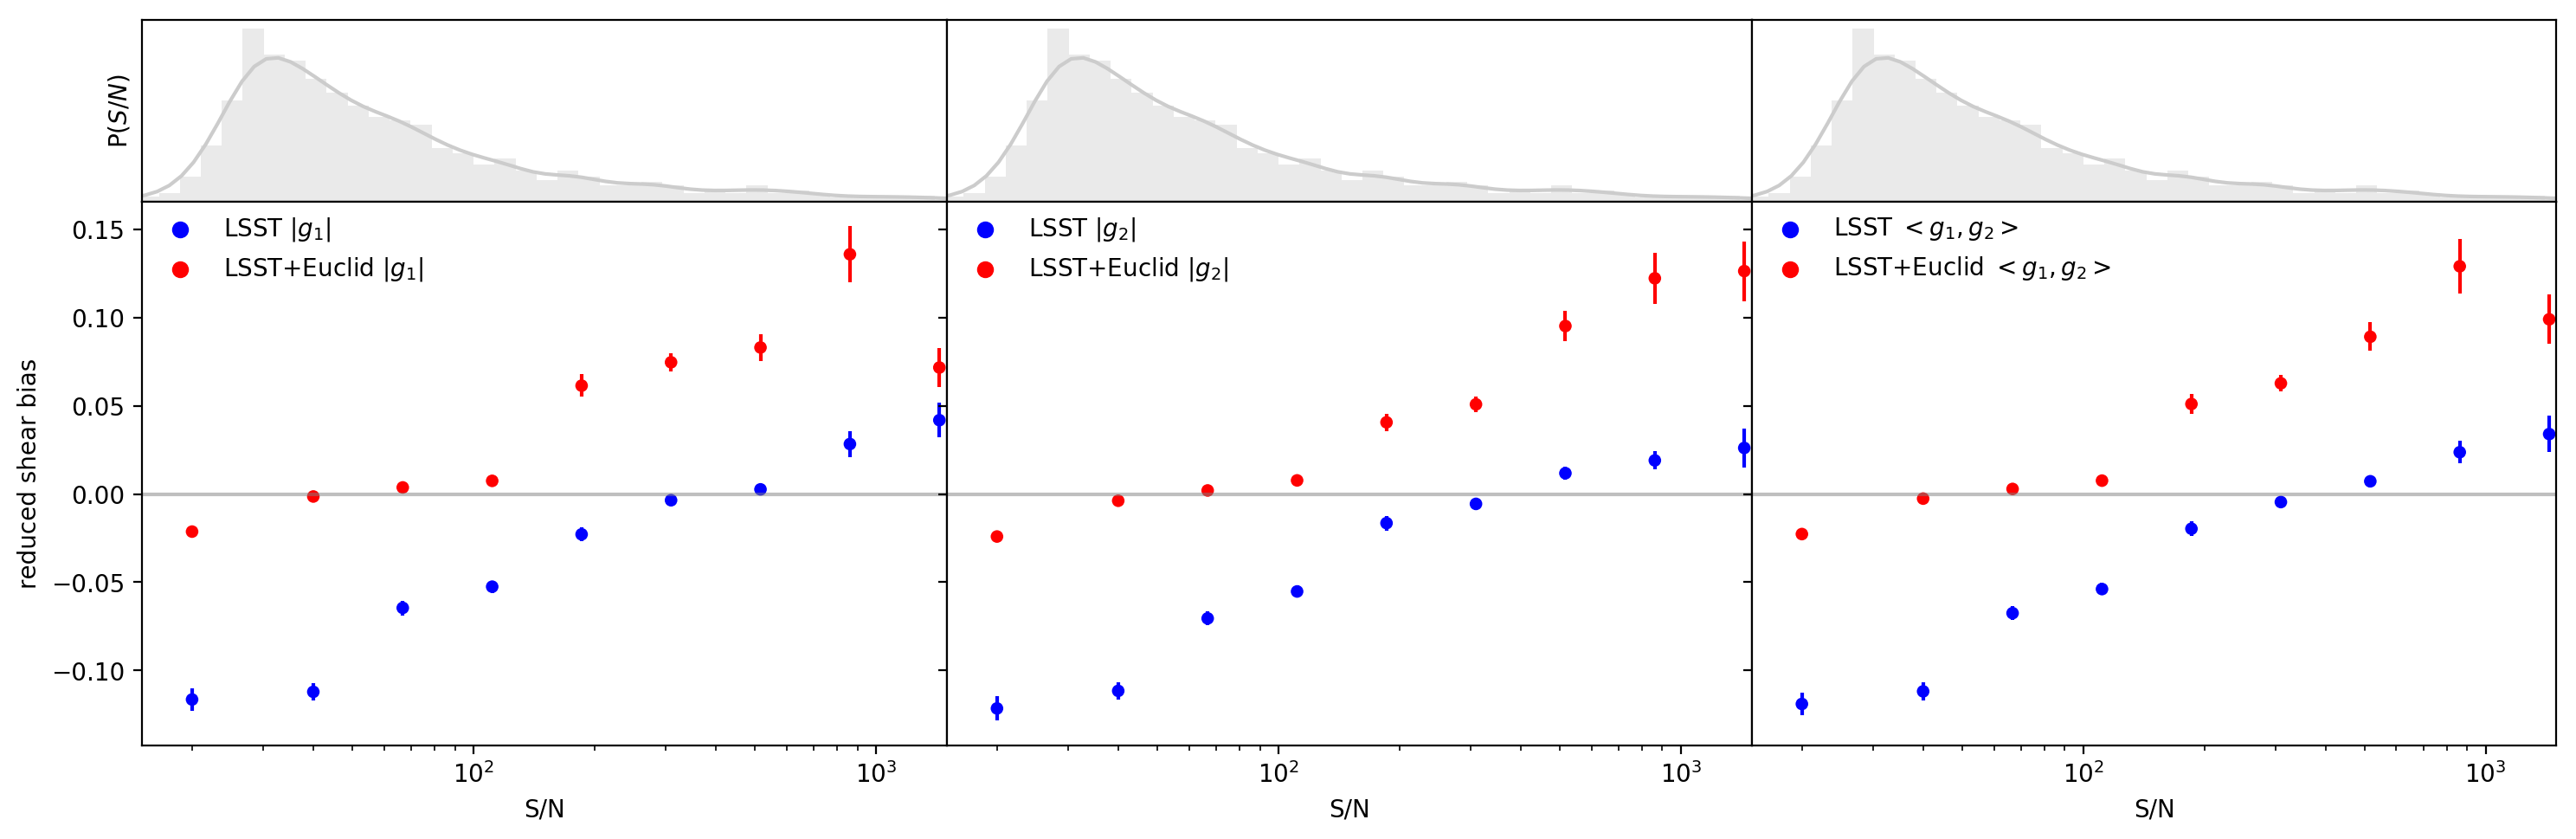

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(15,5),sharey='row', gridspec_kw={'height_ratios': [1, 3]})

palette_lsst = ['blue']
palette_lsst_euclid = ['red']

xlim = (15,1500)
xscale = 'log'

for i in range (3):
    sns.distplot(np.log10(df_lsst[param]), ax=axes[0,i], color='0.8')
    axes[0,i].set_xlim(np.log10(xlim[0]), np.log10(xlim[1]))
axes[0,0].set_ylabel('P($S/N$)')
axes[0,0].set_yticks([])

for k in range (2):
    handles = []
    legend = []

    axis = axes[1,k]
    ax = sns.scatterplot(x="bins_list",
                  y="slope_e"+str(k+1), 
                  hue="Experience",
                  data=df_bias, 
                  markers = '.',
                  palette = [palette_lsst[0], palette_lsst_euclid[0]],
                  label = ['LSST $|g_'+str(k+1)+'|$','LSST+Euclid $|g_'+str(k+1)+'|$'],
                  ax = axis)
    print(ax.get_legend_handles_labels()[1])

    handles.append(ax.get_legend_handles_labels()[0][2])
    handles.append(ax.get_legend_handles_labels()[0][3])
    legend.append('LSST $|g_'+str(k+1)+'|$')
    legend.append('LSST+Euclid $|g_'+str(k+1)+'|$')
    # Find the x,y coordinates for each point
    x_coords = []
    y_coords = []

    for i, idx in enumerate (df_bias['bins_list']):
        x_coords.append(idx)
        y_coords.append(df_bias["slope_e"+str(k+1)][i])

    colors = [palette_lsst[0]]*int(len(df_bias['bins_list'])/2) + [palette_lsst_euclid[0]]*int(len(df_bias['bins_list'])/2)

    axis.errorbar(x_coords, 
                 y_coords, 
                 yerr=df_bias['std_err_e'+str(k+1)],
                 ecolor=colors,
                 fmt=' ')


    axis.legend(handles, legend, frameon=False, loc ='upper left', borderpad = 0.1, fontsize = 10)
    axis.set_xlabel('S/N')
    axis.set_ylabel('reduced shear bias')
    axis.axhline(0,color = 'grey', alpha = 0.5)
    axis.set_xscale(xscale)
    axis.set_xlim(xlim)

 

handles = []
legend = []

axis = axes[1,2]
ax = sns.scatterplot(x="bins_list",
              y="mean_g", 
              hue="Experience",
              data=df_bias, 
              markers = '.',
              palette = [palette_lsst[0], palette_lsst_euclid[0]],
              #label = ['LSST $|g_'+str(k+1)+'|$','LSST+Euclid $|g_'+str(k+1)+'|$'],
              ax = axis)
print(ax.get_legend_handles_labels()[1])

handles.append(ax.get_legend_handles_labels()[0][1])
handles.append(ax.get_legend_handles_labels()[0][2])
legend.append('LSST $<g_1, g_2>$')
legend.append('LSST+Euclid $<g_1, g_2>$')
# Find the x,y coordinates for each point
x_coords = []
y_coords = []

for i, idx in enumerate (df_bias['bins_list']):
    x_coords.append(idx)
    y_coords.append(df_bias["mean_g"][i])

colors = [palette_lsst[0]]*int(len(df_bias['bins_list'])/2) + [palette_lsst_euclid[0]]*int(len(df_bias['bins_list'])/2)

axis.errorbar(x_coords, 
             y_coords, 
             yerr=df_bias['mean_stderr'],
             ecolor=colors,
             fmt=' ')


axis.legend(handles, legend, frameon=False, loc ='upper left', borderpad = 0.1, fontsize = 10)#, colors = ['steelblue','coral','blue','red'])
axis.set_xlabel('S/N')
axis.axhline(0, color = 'grey', alpha = 0.5)
axis.set_xscale(xscale)
axis.set_xlim(xlim)

plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)